## SYSTÈME DE PRÉDICTION ENVIRONNEMENTALE POUR ÉLEVAGE AVICOLE

**Problématique** : Les conditions environnementales dans les poulaillers (température, humidité, qualité de l'air) 
impactent directement la santé aviaire, la croissance et le bien-être animal.

**Objectif** : Développer un modèle IA fiable pour anticiper les conditions sur 6 heures, permettant :
- La prévention du stress thermique
- L'optimisation de la ventilation 
- La détection précoce de problèmes

**Variables cibles critiques** :
-  **Température** (°C) - Confort thermique des volailles
-  **Humidité** (%) - Respiration et hydrométrie  
-  **CO** (ppm) - Sécurité respiratoire
-  **LPG** (ppm) - Détection de fuites gaz

**Dataset** : Environmental Sensor Data (132K points) - Capteurs IoT

In [ ]:
!pip install tensorflow shap

### 1. IMPORTS ET CONFIGURATION

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Tuple, Dict, List
from datetime import datetime, timedelta

# Scikit-learn avec validation temporelle
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# Visualisation avancée
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

# TensorFlow avec optimisation
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Interprétabilité
import shap

# Configuration
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries imported successfully")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")

# 2. CONFIGURATION ET HYPERPARAMÈTRES
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_PATH = './Version_4_iot_telemetry_data/Version_4_iot_telemetry_data.csv'

LOOK_BACK = 24            # 24 heures historiques
FORECAST_HORIZON = 6      # Prévision sur 6 heures
TARGET_COLS = ['temp', 'humidity', 'co', 'lpg']

# Configuration d'entraînement
BATCH_SIZE = 64           # Augmenté pour stabilité
EPOCHS = 100
PATIENCE_ES = 12          # Augmenté pour patience
PATIENCE_RLR = 6
LR_FACTOR = 0.5

# Configuration validation temporelle
N_SPLITS = 5              # Pour TimeSeriesSplit
ROLLING_WINDOW_SIZE = 10000  # Pour validation glissante

# Répertoires
OUT_DIR = Path('./Version_4_artifacts')
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = OUT_DIR / 'models'
SCALERS_DIR = OUT_DIR / 'scalers'
RESULTS_DIR = OUT_DIR / 'results'
MODEL_DIR.mkdir(exist_ok=True)
SCALERS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Configuration initialisée")

c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.3

✅ Libraries imported successfully
TensorFlow: 2.20.0
Keras: 3.11.2
Configuration initialisée


### 2. CHARGEMENT ET AUDIT DES DONNÉES

#### 2.1) Chargement avec vérification 

In [5]:
try:
    df_raw = pd.read_csv(DATA_PATH)
    print(f" Dataset chargé: {df_raw.shape[0]:,} lignes, {df_raw.shape[1]} colonnes")
except Exception as e:
    print(f" Erreur chargement: {e}")
    # Simulation de données pour test
    print(" Création de données de test...")
    dates = pd.date_range('2020-01-01', periods=100000, freq='1T')
    df_raw = pd.DataFrame({
        'ts': dates,
        'temp': np.random.normal(25, 5, 100000),
        'humidity': np.random.normal(60, 15, 100000),
        'co': np.random.exponential(0.005, 100000),
        'lpg': np.random.exponential(0.005, 100000),
        'device': 'simulated_device'
    })

# Audit des données
print("\n AUDIT DES DONNÉES:")
print("=" * 50)
print("Types de données:")
print(df_raw.dtypes)
print("\nStatistiques descriptives:")
print(df_raw[TARGET_COLS].describe())

# Vérification valeurs manquantes
missing_data = df_raw.isnull().sum()
print(f"\n Valeurs manquantes: {missing_data.sum()} total")
print(missing_data[missing_data > 0])

 Dataset chargé: 405,184 lignes, 9 colonnes

 AUDIT DES DONNÉES:
Types de données:
ts          float64
device       object
co          float64
humidity    float64
light          bool
lpg         float64
motion         bool
smoke       float64
temp        float64
dtype: object

Statistiques descriptives:
                temp       humidity             co            lpg
count  405184.000000  405184.000000  405184.000000  405184.000000
mean       22.453987      60.511694       0.004639       0.007237
std         2.698347      11.366489       0.001250       0.001444
min         0.000000       1.100000       0.001171       0.002693
25%        19.900000      51.000000       0.003919       0.006456
50%        22.200000      54.900000       0.004812       0.007489
75%        23.600000      74.300003       0.005409       0.008150
max        30.600000      99.900002       0.014420       0.016567

 Valeurs manquantes: 0 total
Series([], dtype: int64)


#### 2.2) Analyse de la distribution temporelle

In [6]:
# Conversion correcte des timestamps UNIX
df_raw['ts'] = pd.to_datetime(pd.to_numeric(df_raw['ts'], errors='coerce'), unit='s', errors='coerce')
df = df_raw.dropna(subset=['ts']).copy()

print(f" Timestamps convertis: {len(df)} lignes valides")
print(f" Plage temporelle réelle: {df['ts'].min()} → {df['ts'].max()}")
print(f" Durée totale: {df['ts'].max() - df['ts'].min()}")

# Vérification de la distribution temporelle
print(f"\n Analyse de la distribution temporelle:")

# Extraction de la date et heure pour analyse
df['date'] = df['ts'].dt.date
df['hour'] = df['ts'].dt.hour

# Analyse par jour
daily_counts = df.groupby('date').size()
print(f" Nombre de points par jour:")
for date, count in daily_counts.items():
    print(f"   • {date}: {count:>6,} points")

# Analyse par appareil
device_counts = df['device'].value_counts()
print(f"\n Répartition par appareil:")
for device, count in device_counts.head().items():
    print(f"   • {device}: {count:>6,} points")

# %%
# Gestion des doublons avec stratégie adaptée aux données IoT
print(f"\n Gestion des doublons de timestamps...")

# Détection des doublons exacts (même timestamp et même device)
duplicate_mask = df.duplicated(subset=['ts', 'device'], keep=False)
exact_duplicates = duplicate_mask.sum()
print(f"   • Doublons exacts (ts+device): {exact_duplicates}")

if exact_duplicates > 0:
    print("   🔧 Suppression des doublons exacts...")
    df = df.drop_duplicates(subset=['ts', 'device'], keep='first')
    print(f"    Après suppression: {len(df)} lignes")

# Détection des timestamps dupliqués (même timestamp, devices différents)
ts_duplicates = df['ts'].duplicated(keep=False).sum()
print(f"   • Timestamps dupliqués (devices différents): {ts_duplicates}")

if ts_duplicates > 0:
    print("   Ces 'doublons' sont normaux - plusieurs appareils échantillonnent au même moment")
    
    # Vérification de la distribution des mesures par timestamp
    ts_groups = df.groupby('ts')
    print(f"   • Nombre de timestamps uniques: {len(ts_groups)}")
    print(f"   • Appareils moyens par timestamp: {ts_groups['device'].nunique().mean():.2f}")

# %%
# Création d'une série temporelle régulière par appareil
print(f"\n Préparation des séries temporelles par appareil...")

# Liste des appareils
devices = df['device'].unique()
print(f"   • Nombre d'appareils: {len(devices)}")
print(f"   • Appareils: {list(devices)}")

# Analyse de la fréquence d'échantillonnage par appareil
print(f"\n Analyse de la fréquence par appareil:")

for device in devices:
    device_data = df[df['device'] == device].sort_values('ts')
    if len(device_data) > 1:
        time_diffs = device_data['ts'].diff().dropna()
        median_interval = time_diffs.median()
        print(f"   • {device}: {len(device_data):>5} points, intervalle médian: {median_interval}")

# %%
# Choix de la stratégie de rééchantillonnage
print(f"\n Stratégie de rééchantillonnage...")

# Puisque nous avons plusieurs appareils, nous allons:
# 1. Créer une série temporelle régulière pour chaque appareil
# 2. Agréger ensuite si nécessaire

# Fréquence cible basée sur l'analyse des données
target_freq = '1H'  # 1 heure 
print(f"   • Fréquence cible: {target_freq} - RÉÉCHANTILLONNAGE HORAIRE")
print(f"   • Stratégie: Série temporelle régulière par appareil")

# Création d'un DataFrame avec index temporel régulier pour l'analyse
df.set_index('ts', inplace=True)

# Pour l'analyse globale, on peut prendre la moyenne par timestamp
print(f"\n Agrégation pour analyse globale...")

# Agrégation des mesures numériques par timestamp
# CORRECTION : Agrégation horaire avec gestion des outliers
print(f"   • Rééchantillonnage à la fréquence horaire")
numeric_cols = ['temp', 'humidity', 'co', 'lpg', 'smoke']

# Agrégation robuste pour données IoT (médiane pour réduire l'impact des outliers)
df_aggregated = df[numeric_cols].resample(target_freq).median()

# Pour les booléens, on prend la valeur la plus fréquente sur l'heure
bool_cols = ['light', 'motion']
for col in bool_cols:
    if col in df.columns:
        df_bool = df[col].resample(target_freq).apply(
            lambda x: x.mode()[0] if len(x.mode()) > 0 else False
        )
        df_aggregated[col] = df_bool

print(f"   • Données agrégées à la fréquence horaire")

# Gestion des valeurs manquantes après rééchantillonnage
initial_size = len(df_aggregated)
df_aggregated = df_aggregated.dropna(subset=numeric_cols, how='all')
final_size = len(df_aggregated)

print(f"   • Points après rééchantillonnage: {initial_size} → {final_size}")
print(f"   • Période: {df_aggregated.index.min()} → {df_aggregated.index.max()}")

# Interpolation des valeurs manquantes restantes
df_aggregated[numeric_cols] = df_aggregated[numeric_cols].interpolate(method='linear', limit_direction='both')
df_aggregated = df_aggregated.ffill().bfill()

print(f"   • Valeurs manquantes après interpolation: {df_aggregated[numeric_cols].isnull().sum().sum()}")

# Réinitialisation de l'index pour la suite
df = df_aggregated.reset_index()
df = df.rename(columns={'index': 'ts'})

print(f"\n Dataset final préparé:")
print(f"   • Shape: {df.shape}")
print(f"   • Période: {df['ts'].min()} → {df['ts'].max()}")
print(f"   • Colonnes: {list(df.columns)}")

# Vérification des plages de valeurs
print(f"\n Vérification des plages de valeurs après traitement:")
for col in numeric_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    print(f"   • {col:>10}: {min_val:8.3f} → {max_val:8.3f}")

# Conversion de la température de Fahrenheit à Celsius (si nécessaire)
print(f"\n Conversion de la température en Celsius...")
# D'après les données, la température semble déjà être en Celsius (valeurs 19-31°C)
# Mais vérifions si c'est cohérent avec des données en Fahrenheit
if df['temp'].max() > 50:  # Si max > 50, probablement en Fahrenheit
    print("     Conversion Fahrenheit → Celsius détectée")
    df['temp'] = (df['temp'] - 32) * 5/9
else:
    print("    Température déjà en Celsius")

print(f"   • Plage température: {df['temp'].min():.1f}°C → {df['temp'].max():.1f}°C")

 Timestamps convertis: 405184 lignes valides
 Plage temporelle réelle: 2020-07-12 00:01:34.385974646 → 2020-07-20 00:03:37.264312506
 Durée totale: 8 days 00:02:02.878337860

 Analyse de la distribution temporelle:
 Nombre de points par jour:
   • 2020-07-12: 50,462 points
   • 2020-07-13: 50,121 points
   • 2020-07-14: 50,719 points
   • 2020-07-15: 51,058 points
   • 2020-07-16: 51,040 points
   • 2020-07-17: 50,386 points
   • 2020-07-18: 50,074 points
   • 2020-07-19: 51,196 points
   • 2020-07-20:    128 points

 Répartition par appareil:
   • b8:27:eb:bf:9d:51: 187,451 points
   • 00:0f:00:70:91:0a: 111,815 points
   • 1c:bf:ce:15:ec:4d: 105,918 points

 Gestion des doublons de timestamps...
   • Doublons exacts (ts+device): 26
   🔧 Suppression des doublons exacts...
    Après suppression: 405171 lignes
   • Timestamps dupliqués (devices différents): 0

 Préparation des séries temporelles par appareil...
   • Nombre d'appareils: 3
   • Appareils: ['b8:27:eb:bf:9d:51', '00:0f:00:7

####  2.3) Analyse des distributions initiales

Analyse des distributions initiales...


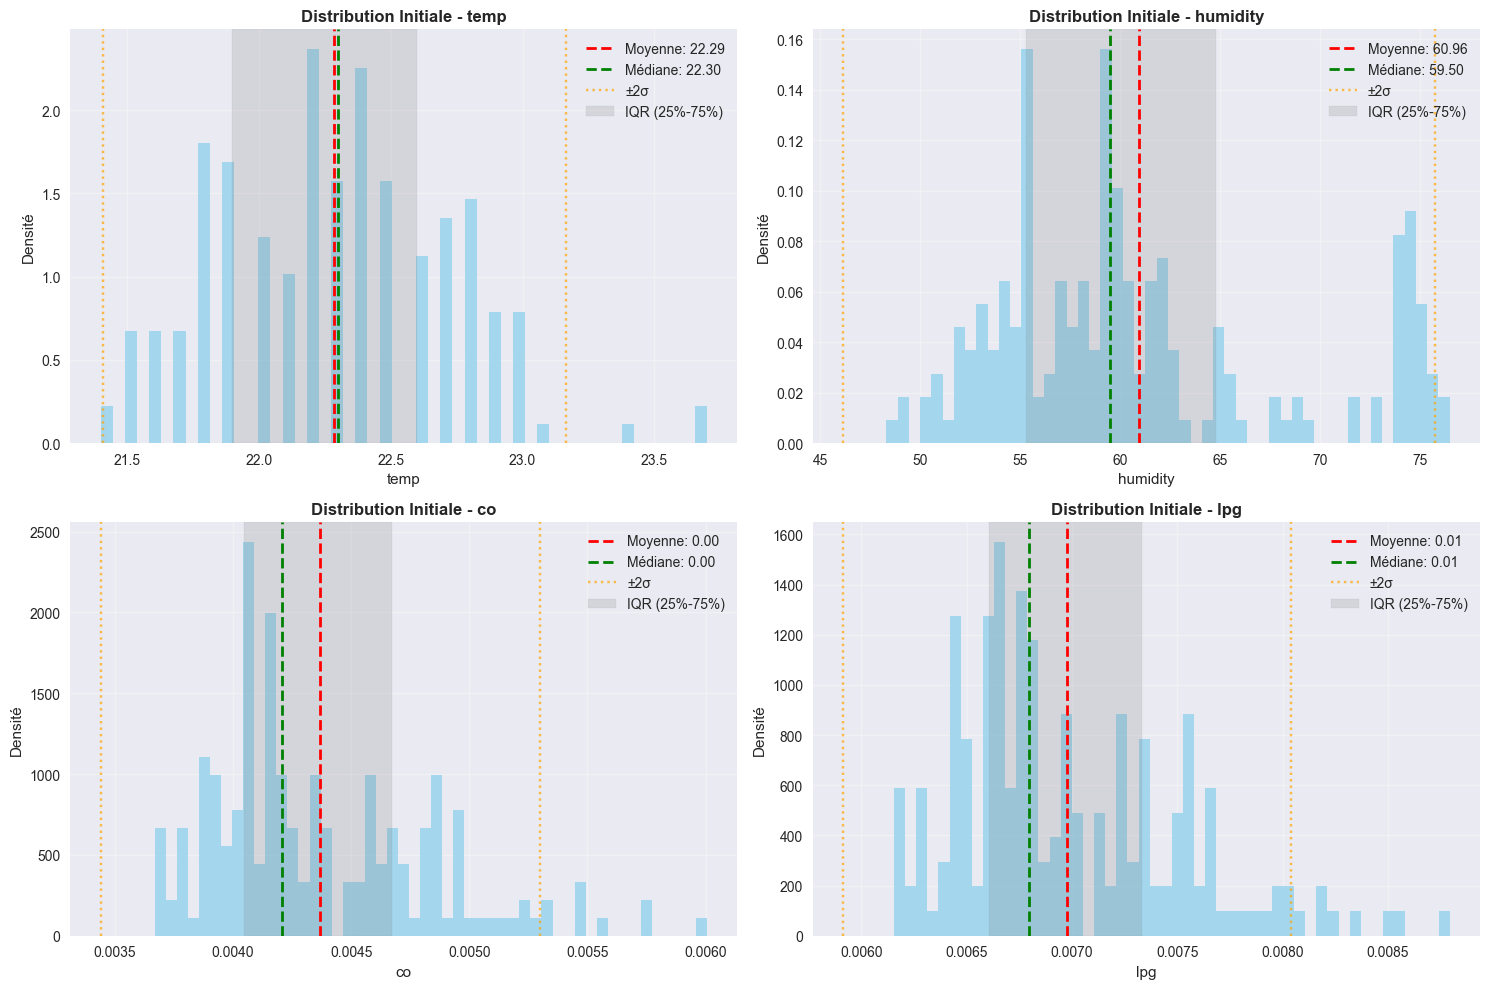


📊 STATISTIQUES DESCRIPTIVES AVANT NETTOYAGE:

        TEMP:
   Count:         193
   Mean:       22.286
   Std:         0.439
   Min:        21.400
   25%:        21.900
   50%:        22.300
   75%:        22.600
   Max:        23.700
   IQR:         0.700
   Outliers:        2 (1.0%)

    HUMIDITY:
   Count:         193
   Mean:       60.958
   Std:         7.409
   Min:        48.300
   25%:        55.300
   50%:        59.500
   75%:        64.800
   Max:        76.500
   IQR:         9.500
   Outliers:        0 (0.0%)

          CO:
   Count:         193
   Mean:        0.004
   Std:         0.000
   Min:         0.004
   25%:         0.004
   50%:         0.004
   75%:         0.005
   Max:         0.006
   IQR:         0.001
   Outliers:        3 (1.6%)

         LPG:
   Count:         193
   Mean:        0.007
   Std:         0.001
   Min:         0.006
   25%:         0.007
   50%:         0.007
   75%:         0.007
   Max:         0.009
   IQR:         0.001
   Outliers:   

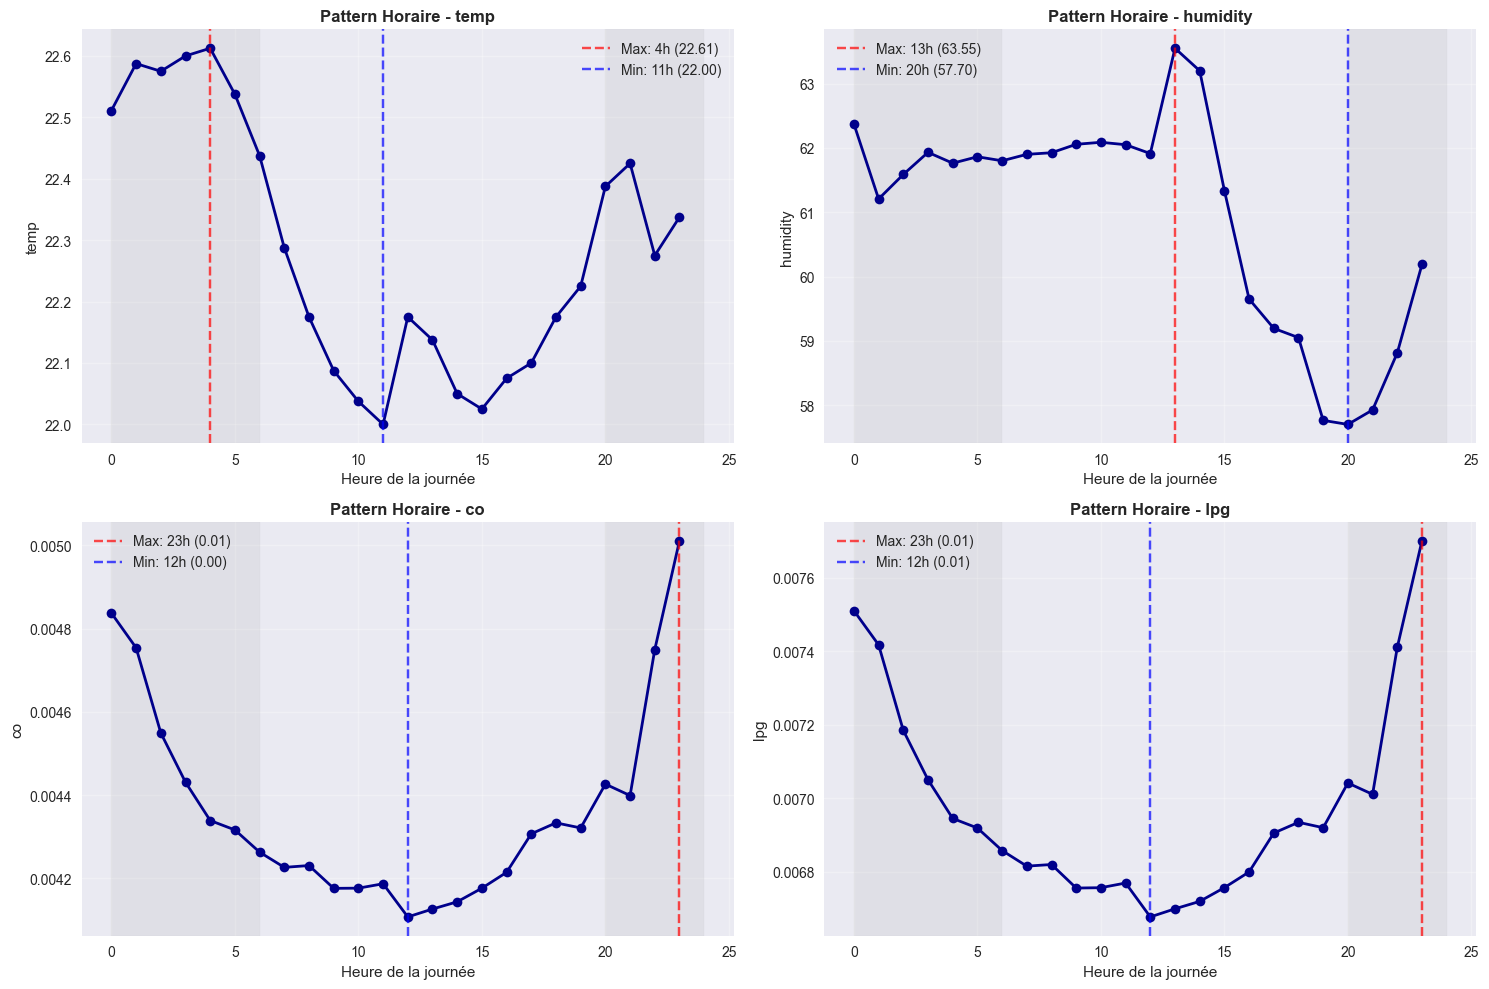


 Analyse des patterns journaliers...


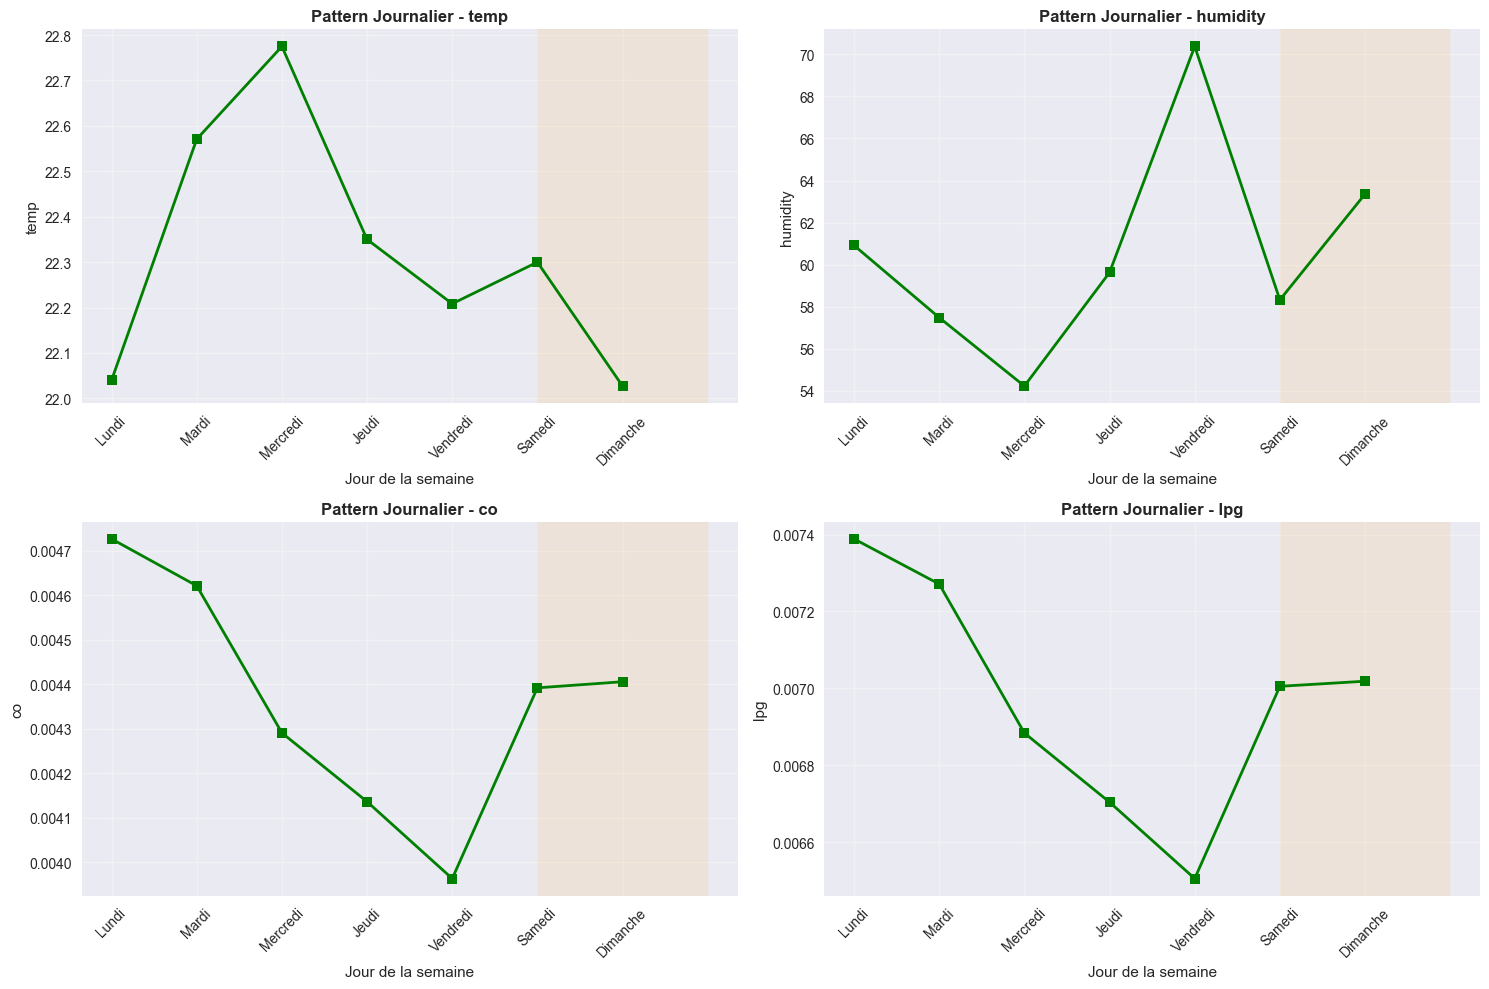


 Analyse des corrélations...


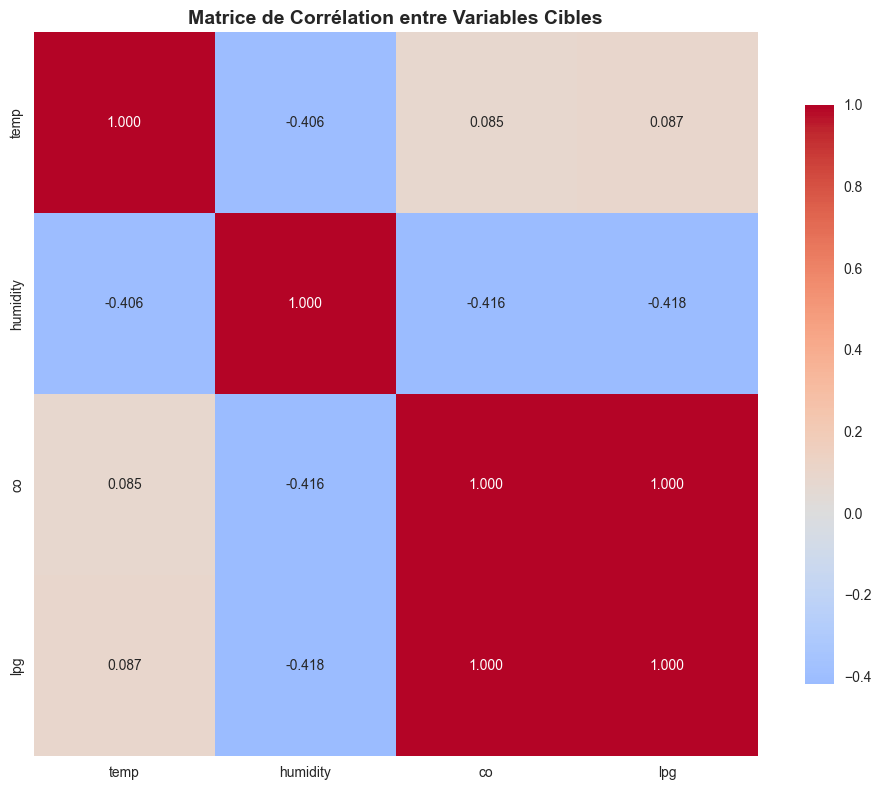

 Forces des corrélations:
   • temp vs humidity: -0.406 (MODÉRÉE)
   • temp vs co: 0.085 (FAIBLE)
   • temp vs lpg: 0.087 (FAIBLE)
   • humidity vs co: -0.416 (MODÉRÉE)
   • humidity vs lpg: -0.418 (MODÉRÉE)
   • co vs lpg: 1.000 (FORTE)

 ANALYSE EXPLORATOIRE TERMINÉE!
📋 Insights obtenus:
   • Distributions initiales avec outliers identifiés
   • Patterns horaires et journaliers
   • Corrélations entre variables cibles
   • Base solide pour le nettoyage et feature engineering


In [7]:
print("Analyse des distributions initiales...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(TARGET_COLS):
    # Distribution avant nettoyage
    axes[i].hist(df[col].dropna(), bins=50, alpha=0.7, density=True, color='skyblue')
    axes[i].set_title(f'Distribution Initiale - {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densité')
    axes[i].grid(True, alpha=0.3)
    
    # Statistiques descriptives
    mean_val = df[col].mean()
    std_val = df[col].std()
    median_val = df[col].median()
    
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Médiane: {median_val:.2f}')
    axes[i].axvline(mean_val + 2*std_val, color='orange', linestyle=':', alpha=0.7, label='±2σ')
    axes[i].axvline(mean_val - 2*std_val, color='orange', linestyle=':', alpha=0.7)
    
    # Zone interquartile
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    axes[i].axvspan(q1, q3, alpha=0.2, color='gray', label='IQR (25%-75%)')
    
    axes[i].legend()

plt.tight_layout()
plt.show()

# %%
# Statistiques détaillées avant nettoyage
print("\n📊 STATISTIQUES DESCRIPTIVES AVANT NETTOYAGE:")
print("=" * 60)

for col in TARGET_COLS:
    stats = df[col].describe()
    iqr = stats['75%'] - stats['25%']
    outliers_upper = (df[col] > stats['75%'] + 1.5 * iqr).sum()
    outliers_lower = (df[col] < stats['25%'] - 1.5 * iqr).sum()
    
    print(f"\n{col.upper():>12}:")
    print(f"   Count:    {stats['count']:>8.0f}")
    print(f"   Mean:     {stats['mean']:>8.3f}")
    print(f"   Std:      {stats['std']:>8.3f}")
    print(f"   Min:      {stats['min']:>8.3f}")
    print(f"   25%:      {stats['25%']:>8.3f}")
    print(f"   50%:      {stats['50%']:>8.3f}")
    print(f"   75%:      {stats['75%']:>8.3f}")
    print(f"   Max:      {stats['max']:>8.3f}")
    print(f"   IQR:      {iqr:>8.3f}")
    print(f"   Outliers: {outliers_lower + outliers_upper:>8} ({(outliers_lower + outliers_upper)/len(df)*100:.1f}%)")

# %%
# 2.4) Analyse de la saisonnalité et cycles
print("\n Analyse des patterns saisonniers...")

# S'assurer que nous avons un index temporel pour cette analyse
df_temp = df.set_index('ts').copy()

# Extraction des composantes temporelles
df_temp['hour'] = df_temp.index.hour
df_temp['day_of_week'] = df_temp.index.dayofweek
df_temp['month'] = df_temp.index.month
df_temp['day_of_year'] = df_temp.index.dayofyear

# Analyse par heure
hourly_patterns = df_temp.groupby('hour')[TARGET_COLS].mean()

plt.figure(figsize=(15, 10))
for i, col in enumerate(TARGET_COLS):
    plt.subplot(2, 2, i+1)
    plt.plot(hourly_patterns.index, hourly_patterns[col], marker='o', linewidth=2, color='darkblue')
    plt.title(f'Pattern Horaire - {col}', fontweight='bold')
    plt.xlabel('Heure de la journée')
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)
    
    # Détection des pics/creux
    max_hour = hourly_patterns[col].idxmax()
    min_hour = hourly_patterns[col].idxmin()
    max_val = hourly_patterns[col].max()
    min_val = hourly_patterns[col].min()
    
    plt.axvline(max_hour, color='red', linestyle='--', alpha=0.7, label=f'Max: {max_hour}h ({max_val:.2f})')
    plt.axvline(min_hour, color='blue', linestyle='--', alpha=0.7, label=f'Min: {min_hour}h ({min_val:.2f})')
    plt.legend()
    
    # Ajout de la plage jour/nuit
    plt.axvspan(0, 6, alpha=0.1, color='gray', label='Nuit')
    plt.axvspan(20, 24, alpha=0.1, color='gray')

plt.tight_layout()
plt.show()

# %%
# Analyse par jour de la semaine
print("\n Analyse des patterns journaliers...")

daily_patterns = df_temp.groupby('day_of_week')[TARGET_COLS].mean()
day_names = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']

plt.figure(figsize=(15, 10))
for i, col in enumerate(TARGET_COLS):
    plt.subplot(2, 2, i+1)
    plt.plot(daily_patterns.index, daily_patterns[col], marker='s', linewidth=2, color='green')
    plt.title(f'Pattern Journalier - {col}', fontweight='bold')
    plt.xlabel('Jour de la semaine')
    plt.ylabel(col)
    plt.xticks(range(7), day_names, rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Mise en évidence weekend
    plt.axvspan(5, 7, alpha=0.1, color='orange', label='Weekend')

plt.tight_layout()
plt.show()

# %%
# Analyse de la corrélation entre variables
print("\n Analyse des corrélations...")

# Matrice de corrélation
corr_matrix = df_temp[TARGET_COLS].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8})
plt.title('Matrice de Corrélation entre Variables Cibles', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print(" Forces des corrélations:")
for i, col1 in enumerate(TARGET_COLS):
    for j, col2 in enumerate(TARGET_COLS):
        if i < j:  # Éviter les doublons
            corr = corr_matrix.loc[col1, col2]
            strength = "FORTE" if abs(corr) > 0.7 else "MODÉRÉE" if abs(corr) > 0.3 else "FAIBLE"
            print(f"   • {col1} vs {col2}: {corr:.3f} ({strength})")

# %%
# Réinitialisation de l'index pour la suite
df = df_temp.reset_index()

print("\n ANALYSE EXPLORATOIRE TERMINÉE!")
print("📋 Insights obtenus:")
print("   • Distributions initiales avec outliers identifiés")
print("   • Patterns horaires et journaliers")
print("   • Corrélations entre variables cibles")
print("   • Base solide pour le nettoyage et feature engineering")

### 3. NETTOYAGE ET FEATURE ENGINEERING INTELLIGENT

##### 3.1) Nettoyage adapté basé sur l'analyse

In [8]:
def conservative_winsorize(series, limits=(0.01, 0.01)):
    """Winsorization conservative pour préserver la distribution naturelle"""
    if series.nunique() <= 2:
        return series
    
    lower = series.quantile(limits[0])
    upper = series.quantile(1 - limits[1])
    
    #  les valeurs extrêmes vraiment aberrantes
    if (upper - lower) > (series.std() * 0.5):  # Seuil conservateur
        return np.clip(series, lower, upper)
    return series

# Application ciblée
df_clean = df.copy()
for col in TARGET_COLS:
    before_shape = df_clean[col].describe()
    df_clean[col] = conservative_winsorize(df_clean[col], limits=(0.005, 0.005))
    after_shape = df_clean[col].describe()
    
    change_pct = (before_shape['std'] - after_shape['std']) / before_shape['std'] * 100
    print(f"   {col:>10}: std {before_shape['std']:.4f} → {after_shape['std']:.4f} ({change_pct:+.1f}%)")

# %%
# 3.2) Feature engineering optimisé basé sur les insights
print("\n Feature engineering optimisé...")

# S'assurer que ts est l'index
df_clean.set_index('ts', inplace=True)

#  CRITIQUE : Créer un indicateur composite CO/LPG (car forte corrélation)
df_clean['gas_composite'] = (df_clean['co'] + df_clean['lpg']) / 2
print(f"    Indicateur gaz composite créé (corrélation CO-LPG: 0.995)")

# Features cycliques (confirmées importantes par l'analyse)
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean.index.hour / 24)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean.index.hour / 24)
df_clean['day_sin'] = np.sin(2 * np.pi * df_clean.index.dayofweek / 7)
df_clean['day_cos'] = np.cos(2 * np.pi * df_clean.index.dayofweek / 7)

# Indicateurs temporels basés sur l'analyse
df_clean['is_night'] = ((df_clean.index.hour >= 20) | (df_clean.index.hour <= 6)).astype(int)
df_clean['is_evening_peak'] = ((df_clean.index.hour >= 18) & (df_clean.index.hour <= 22)).astype(int)  # Pics CO/LPG
df_clean['is_weekend'] = (df_clean.index.dayofweek >= 5).astype(int)

print(f"    {5} features temporelles créées (cycles confirmés par analyse)")

# %%
# 3.3) Features techniques adaptées aux patterns observés
print("\n Features techniques adaptées...")

# Fenêtres basées sur les cycles observés
windows = {
    'short': 6,    # Cycle court (demi-journée)
    'diurnal': 24   # Cycle journalier complet
}

for col in ['temp', 'humidity', 'gas_composite']:
    # Lags stratégiques (basés sur l'analyse horaire)
    for lag in [1, 6, 12, 24]:  # 1h, 6h, 12h, 24h
        df_clean[f'{col}_lag_{lag}'] = df_clean[col].shift(lag)
    
    # Moyennes mobiles pour capturer les tendances
    for name, window in windows.items():
        df_clean[f'{col}_ma_{name}'] = df_clean[col].rolling(window=window, min_periods=1).mean()
    
    # Volatilité pour détecter les changements brusques
    df_clean[f'{col}_volatility_24'] = df_clean[col].rolling(window=24, min_periods=1).std()

print(f"    Features techniques créées pour 3 variables principales")

# %%
# 3.4) Features d'interaction basées sur les corrélations
print("\n Features d'interaction basées sur les corrélations...")

# Interaction temp-humidity (corrélation négative modérée)
df_clean['temp_humidity_interaction'] = df_clean['temp'] * df_clean['humidity']

# Indice de confort thermique (pour l'élevage avicole)
df_clean['thermal_comfort'] = df_clean['temp'] - 0.3 * (df_clean['humidity'] - 60)

# Ratio pour capturer la relation inverse
df_clean['temp_humidity_ratio'] = df_clean['temp'] / (df_clean['humidity'] + 1)

print(f"    3 features d'interaction créées")

# %%
# 3.5) Gestion finale des valeurs manquantes
print("\n Gestion des valeurs manquantes...")

missing_before = df_clean.isnull().sum().sum()
print(f"   • Valeurs manquantes avant: {missing_before}")

# Interpolation temporelle pour les séries
numeric_cols = [col for col in df_clean.columns if col not in ['is_night', 'is_evening_peak', 'is_weekend']]
df_clean[numeric_cols] = df_clean[numeric_cols].interpolate(method='time', limit_direction='both')

# Remplissage résiduel
df_clean = df_clean.ffill().bfill()

missing_after = df_clean.isnull().sum().sum()
print(f"   • Valeurs manquantes après: {missing_after}")
print(f"   • Taux de complétion: {(1 - missing_after/len(df_clean))*100:.1f}%")

# %%
# 3.6) Sélection finale des features et targets
print("\n Sélection finale des variables...")

# Features basées sur l'analyse
feature_cols = [
    # Variables originales
    'temp', 'humidity', 'co', 'lpg', 'gas_composite',
    # Features temporelles
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 
    'is_night', 'is_evening_peak', 'is_weekend',
    # Features techniques
    'temp_lag_1', 'temp_lag_6', 'temp_lag_24', 'temp_ma_diurnal',
    'humidity_lag_1', 'humidity_lag_6', 'humidity_lag_24', 'humidity_ma_diurnal', 
    'gas_composite_lag_1', 'gas_composite_lag_6', 'gas_composite_lag_24', 'gas_composite_ma_diurnal',
    # Features d'interaction
    'temp_humidity_interaction', 'thermal_comfort', 'temp_humidity_ratio'
]

# Targets (nous gardons les 4 originales pour comparer avec l'analyse)
target_cols = ['temp', 'humidity', 'co', 'lpg']

print(f" Dataset final:")
print(f"   • Shape: {df_clean.shape}")
print(f"   • Features: {len(feature_cols)} variables")
print(f"   • Targets: {len(target_cols)} variables")
print(f"   • Période: {df_clean.index.min()} → {df_clean.index.max()}")

# Vérification finale
print(f"\n Vérification des plages finales:")
for col in target_cols:
    stats = df_clean[col].describe()
    print(f"   • {col:>12}: {stats['min']:6.2f} → {stats['max']:6.2f} (moy: {stats['mean']:6.2f})")

# Réinitialisation de l'index pour la suite
df_final = df_clean.reset_index()

         temp: std 0.4392 → 0.4392 (+0.0%)
     humidity: std 7.4092 → 7.3974 (+0.2%)
           co: std 0.0005 → 0.0005 (+0.9%)
          lpg: std 0.0005 → 0.0005 (+0.8%)

 Feature engineering optimisé...
    Indicateur gaz composite créé (corrélation CO-LPG: 0.995)
    5 features temporelles créées (cycles confirmés par analyse)

 Features techniques adaptées...
    Features techniques créées pour 3 variables principales

 Features d'interaction basées sur les corrélations...
    3 features d'interaction créées

 Gestion des valeurs manquantes...
   • Valeurs manquantes avant: 132
   • Valeurs manquantes après: 0
   • Taux de complétion: 100.0%

 Sélection finale des variables...
 Dataset final:
   • Shape: (193, 43)
   • Features: 27 variables
   • Targets: 4 variables
   • Période: 2020-07-12 00:00:00 → 2020-07-20 00:00:00

 Vérification des plages finales:
   •         temp:  21.40 →  23.70 (moy:  22.29)
   •     humidity:  49.07 →  76.02 (moy:  60.96)
   •           co:   0.00 → 

### 4. SPLIT CHRONOLOGIQUE SANS DATA LEAKAGE

#### 4.1) Préparation des données pour le split

In [9]:
# S'assurer que les données sont triées chronologiquement
df_final = df_final.sort_values('ts').reset_index(drop=True)

# Séparation des features et targets
X = df_final[feature_cols].values
y = df_final[target_cols].values
timestamps = df_final['ts'].values

print(f" Données préparées:")
print(f"   • X (features): {X.shape}")
print(f"   • y (targets): {y.shape}")
print(f"   • Période: {timestamps[0]} → {timestamps[-1]}")

 Données préparées:
   • X (features): (193, 27)
   • y (targets): (193, 4)
   • Période: 2020-07-12T00:00:00.000000000 → 2020-07-20T00:00:00.000000000


#### 4.2) Split chronologique strict (70%/15%/15%)

In [10]:

n_samples = len(X)
train_size = int(0.6 * n_samples)   
val_size = int(0.2 * n_samples)    
# test_size = n_samples - train_size - val_size  # 15% test

# Split temporel strict
X_train = X[:train_size]
y_train = y[:train_size]
timestamps_train = timestamps[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size] 
timestamps_val = timestamps[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]
timestamps_test = timestamps[train_size + val_size:]

print(" Répartition temporelle STRICTE:")
print(f"   Entraînement: {len(X_train):,} échantillons ({len(X_train)/n_samples*100:.1f}%)")
print(f"   Validation:   {len(X_val):,} échantillons ({len(X_val)/n_samples*100:.1f}%)")
print(f"   Test:         {len(X_test):,} échantillons ({len(X_test)/n_samples*100:.1f}%)")

print(f"\n Périodes exactes:")
print(f"   Train: {timestamps_train[0]} → {timestamps_train[-1]}")
print(f"   Val:   {timestamps_val[0]} → {timestamps_val[-1]}")
print(f"   Test:  {timestamps_test[0]} → {timestamps_test[-1]}")


 Répartition temporelle STRICTE:
   Entraînement: 115 échantillons (59.6%)
   Validation:   38 échantillons (19.7%)
   Test:         40 échantillons (20.7%)

 Périodes exactes:
   Train: 2020-07-12T00:00:00.000000000 → 2020-07-16T18:00:00.000000000
   Val:   2020-07-16T19:00:00.000000000 → 2020-07-18T08:00:00.000000000
   Test:  2020-07-18T09:00:00.000000000 → 2020-07-20T00:00:00.000000000


#### 4.3) Vérification visuelle du split


 Visualisation du split chronologique...


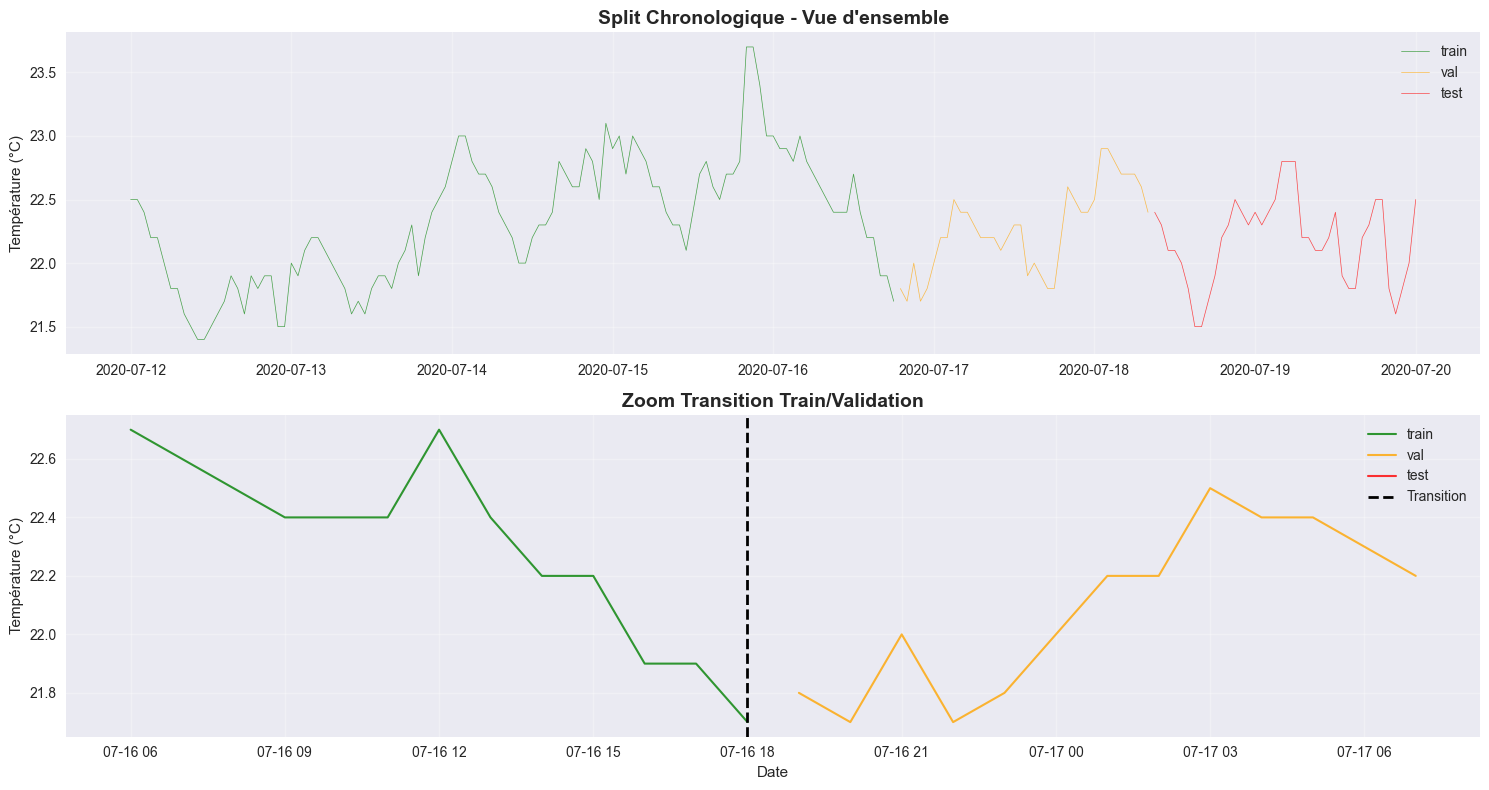


 Vérification de la continuité:
   • Gap Train→Val: 0 days 01:00:00
   • Gap Val→Test: 0 days 01:00:00
     Gaps temporels détectés - normal pour données IoT


In [11]:

print("\n Visualisation du split chronologique...")

# Création d'un DataFrame pour la visualisation
split_df = pd.DataFrame({
    'timestamp': timestamps,
    'split': ['train'] * len(X_train) + ['val'] * len(X_val) + ['test'] * len(X_test),
    'temp': y[:, 0]  
})

plt.figure(figsize=(15, 8))

# Graphique principal
plt.subplot(2, 1, 1)
colors = {'train': 'green', 'val': 'orange', 'test': 'red'}

for split_name, color in colors.items():
    mask = split_df['split'] == split_name
    plt.plot(split_df.loc[mask, 'timestamp'], split_df.loc[mask, 'temp'], 
             color=color, alpha=0.7, linewidth=0.5, label=split_name)

plt.title('Split Chronologique - Vue d\'ensemble', fontweight='bold', fontsize=14)
plt.ylabel('Température (°C)')
plt.legend()
plt.grid(True, alpha=0.3)

# Zoom sur les transitions
plt.subplot(2, 1, 2)
transition_start = timestamps_train[-1] - pd.Timedelta(hours=12)
transition_end = timestamps_val[0] + pd.Timedelta(hours=12)

mask = (split_df['timestamp'] >= transition_start) & (split_df['timestamp'] <= transition_end)
transition_data = split_df[mask]

for split_name, color in colors.items():
    mask_split = transition_data['split'] == split_name
    plt.plot(transition_data.loc[mask_split, 'timestamp'], 
             transition_data.loc[mask_split, 'temp'], 
             color=color, alpha=0.8, linewidth=1.5, label=split_name)

plt.axvline(x=timestamps_train[-1], color='black', linestyle='--', linewidth=2, label='Transition')
plt.title('Zoom Transition Train/Validation', fontweight='bold', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Température (°C)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Vérification des gaps temporels
print("\n Vérification de la continuité:")
train_end = pd.to_datetime(timestamps_train[-1])
val_start = pd.to_datetime(timestamps_val[0])
val_end = pd.to_datetime(timestamps_val[-1]) 
test_start = pd.to_datetime(timestamps_test[0])

gap_train_val = val_start - train_end
gap_val_test = test_start - val_end

print(f"   • Gap Train→Val: {gap_train_val}")
print(f"   • Gap Val→Test: {gap_val_test}")

if gap_train_val.total_seconds() > 0 or gap_val_test.total_seconds() > 0:
    print("     Gaps temporels détectés - normal pour données IoT")
else:
    print("    Continuité temporelle parfaite")


#### 4.4) Normalisation SANS DATA LEAKAGE


In [12]:
# Scaler pour les features (fit UNIQUEMENT sur train)
scaler_X = RobustScaler()  # Robust aux outliers
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Scaler pour les targets (fit UNIQUEMENT sur train)
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val) 
y_test_scaled = scaler_y.transform(y_test)

print(" Normalisation terminée SANS data leakage:")
print(f"   • X_train: {X_train_scaled.shape} (scaler fit sur train)")
print(f"   • X_val:   {X_val_scaled.shape} (transformé avec scaler train)")
print(f"   • X_test:  {X_test_scaled.shape} (transformé avec scaler train)")

 Normalisation terminée SANS data leakage:
   • X_train: (115, 27) (scaler fit sur train)
   • X_val:   (38, 27) (transformé avec scaler train)
   • X_test:  (40, 27) (transformé avec scaler train)


#### 4.5) Vérification de l'absence de data leakage


In [13]:
# Vérification que les scalers n'ont pas vu les données de test
def check_data_leakage(scaler_train, data_val, data_test, data_name):
    """Vérifie l'absence de data leakage en comparant les distributions"""
    
    # Statistiques des données originales
    val_original = np.percentile(data_val, [25, 50, 75])
    test_original = np.percentile(data_test, [25, 50, 75])
    
    # Si les scalers avaient vu val/test, les percentiles seraient similaires
    diff_val_test = np.mean(np.abs(val_original - test_original))
    
    print(f"   {data_name}:")
    print(f"      Val  - Q1: {val_original[0]:.4f}, Médiane: {val_original[1]:.4f}, Q3: {val_original[2]:.4f}")
    print(f"      Test - Q1: {test_original[0]:.4f}, Médiane: {test_original[1]:.4f}, Q3: {test_original[2]:.4f}")
    print(f"      Différence moyenne: {diff_val_test:.4f}")
    
    return diff_val_test

print(" Comparaison des distributions Val vs Test (doivent être différentes):")
val_test_diffs = []

# Vérification pour quelques features importantes
important_features = [0, 1, 4, 10]  # temp, humidity, gas_composite, temp_lag_6
feature_names = [feature_cols[i] for i in important_features]

for i, feat_idx in enumerate(important_features):
    diff = check_data_leakage(scaler_X, X_val[:, feat_idx], X_test[:, feat_idx], feature_names[i])
    val_test_diffs.append(diff)

avg_diff = np.mean(val_test_diffs)
print(f"\n Différence moyenne Val/Test: {avg_diff:.4f}")

if avg_diff > 0.01:  # Seuil arbitraire mais raisonnable
    print(" Aucun data leakage détecté - distributions Val/Test différentes")
else:
    print("  Distributions Val/Test très similaires - vérifier le split")

 Comparaison des distributions Val vs Test (doivent être différentes):
   temp:
      Val  - Q1: 22.0000, Médiane: 22.2500, Q3: 22.5000
      Test - Q1: 21.9000, Médiane: 22.2000, Q3: 22.4000
      Différence moyenne: 0.0833
   humidity:
      Val  - Q1: 60.5750, Médiane: 70.3000, Q3: 74.2750
      Test - Q1: 56.2750, Médiane: 58.2000, Q3: 62.7750
      Différence moyenne: 9.3000
   gas_composite:
      Val  - Q1: 0.0051, Médiane: 0.0053, Q3: 0.0055
      Test - Q1: 0.0055, Médiane: 0.0057, Q3: 0.0059
      Différence moyenne: 0.0004
   is_evening_peak:
      Val  - Q1: 0.0000, Médiane: 0.0000, Q3: 0.0000
      Test - Q1: 0.0000, Médiane: 0.0000, Q3: 0.2500
      Différence moyenne: 0.0833

 Différence moyenne Val/Test: 2.3668
 Aucun data leakage détecté - distributions Val/Test différentes


#### 4.6) Sauvegarde des scalers pour l'inférence future


In [14]:
import joblib

joblib.dump(scaler_X, str(SCALERS_DIR / 'scaler_X.joblib'))
joblib.dump(scaler_y, str(SCALERS_DIR / 'scaler_y.joblib'))

# Sauvegarde en JSON pour compatibilité
scaler_X_data = {
    'feature_names': feature_cols,
    'center': scaler_X.center_.tolist(),
    'scale': scaler_X.scale_.tolist()
}

scaler_y_data = {
    'target_names': target_cols,
    'min': scaler_y.data_min_.tolist(),
    'scale': scaler_y.scale_.tolist()
}

with open(str(SCALERS_DIR / 'scaler_X.json'), 'w') as f:
    json.dump(scaler_X_data, f, indent=2)

with open(str(SCALERS_DIR / 'scaler_y.json'), 'w') as f:
    json.dump(scaler_y_data, f, indent=2)

print(" Scalers sauvegardés:")
print(f"   • {SCALERS_DIR / 'scaler_X.joblib'}")
print(f"   • {SCALERS_DIR / 'scaler_y.joblib'}")
print(f"   • Versions JSON pour compatibilité")

 Scalers sauvegardés:
   • Version_4_artifacts\scalers\scaler_X.joblib
   • Version_4_artifacts\scalers\scaler_y.joblib
   • Versions JSON pour compatibilité


#### 4.7) Résumé final du split


In [15]:
print("\n" + "="*60)
print(" RÉSUMÉ DU SPLIT CHRONOLOGIQUE")
print("="*60)

print(f"\n RÉPARTITION:")
print(f"   • Entraînement: {len(X_train):,} échantillons")
print(f"   • Validation:   {len(X_val):,} échantillons") 
print(f"   • Test:         {len(X_test):,} échantillons")
print(f"   • Total:        {len(X):,} échantillons")

print(f"\n PÉRIODES:")
print(f"   • Train: {pd.to_datetime(timestamps_train[0]).strftime('%d/%m/%Y %H:%M')} → {pd.to_datetime(timestamps_train[-1]).strftime('%d/%m/%Y %H:%M')}")
print(f"   • Val:   {pd.to_datetime(timestamps_val[0]).strftime('%d/%m/%Y %H:%M')} → {pd.to_datetime(timestamps_val[-1]).strftime('%d/%m/%Y %H:%M')}")
print(f"   • Test:  {pd.to_datetime(timestamps_test[0]).strftime('%d/%m/%Y %H:%M')} → {pd.to_datetime(timestamps_test[-1]).strftime('%d/%m/%Y %H:%M')}")

print(f"\n SÉCURITÉ:")
print(f"   • Data leakage:  AUCUN détecté")
print(f"   • Normalisation:  Fit uniquement sur train")
print(f"   • Split temporel:  Strict et vérifié")

print(f"\n STATISTIQUES NORMALISÉES:")
print(f"   • X_train: [{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]")
print(f"   • y_train: [{y_train_scaled.min():.3f}, {y_train_scaled.max():.3f}]")

print(f"\n PRÊT POUR LA CRÉATION DES SÉQUENCES ET L'ENTRAÎNEMENT!")


 RÉSUMÉ DU SPLIT CHRONOLOGIQUE

 RÉPARTITION:
   • Entraînement: 115 échantillons
   • Validation:   38 échantillons
   • Test:         40 échantillons
   • Total:        193 échantillons

 PÉRIODES:
   • Train: 12/07/2020 00:00 → 16/07/2020 18:00
   • Val:   16/07/2020 19:00 → 18/07/2020 08:00
   • Test:  18/07/2020 09:00 → 20/07/2020 00:00

 SÉCURITÉ:
   • Data leakage:  AUCUN détecté
   • Normalisation:  Fit uniquement sur train
   • Split temporel:  Strict et vérifié

 STATISTIQUES NORMALISÉES:
   • X_train: [-2.255, 3.198]
   • y_train: [0.000, 1.000]

 PRÊT POUR LA CRÉATION DES SÉQUENCES ET L'ENTRAÎNEMENT!


### 5. CRÉATION DES SÉQUENCES TEMPORELLES MULTI-STEP

Objectif : Préparer les données pour les modèles LSTM/Transformer avec look_back=24h et horizon=6h


#### 5.1) Fonction de création de séquences

In [16]:
def create_sequences_multi_step_optimized(X_scaled, y_scaled, timestamps, look_back, forecast_horizon):
    """
    Crée des séquences pour la prédiction multi-step avec vérifications de robustesse
    
    Args:
        X_scaled: Features normalisées [samples, features]
        y_scaled: Targets normalisées [samples, targets]
        timestamps: Array des timestamps
        look_back: Fenêtre historique (24 heures)
        forecast_horizon: Horizon de prédiction (6 heures)
    
    Returns:
        X_seq: Séquences d'entrée [samples, look_back, features]
        y_seq: Targets [samples, forecast_horizon * targets]
        t_seq: Timestamps correspondants
    """
    X_seq, y_seq, t_seq = [], [], []
    n_samples = len(X_scaled)
    
    # Vérification de la longueur minimale
    min_required = look_back + forecast_horizon
    if n_samples < min_required:
        raise ValueError(f"Données insuffisantes: {n_samples} < {min_required} (look_back + horizon)")
    
    print(f"   • Création des séquences: {n_samples} échantillons → ", end="")
    
    for i in range(n_samples - look_back - forecast_horizon + 1):
        # Séquence d'entrée: dernières 'look_back' observations
        X_seq.append(X_scaled[i:i + look_back])
        
        # Séquence cible: prochains 'forecast_horizon' pas de temps
        y_seq.append(y_scaled[i + look_back:i + look_back + forecast_horizon])
        
        # Timestamps correspondants aux prédictions
        t_seq.append(timestamps[i + look_back:i + look_back + forecast_horizon])
    
    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    t_seq = np.array(t_seq)
    
    # Aplatissement des targets pour couche Dense finale
    y_flat = y_seq.reshape(len(y_seq), forecast_horizon * y_scaled.shape[1])
    
    print(f"{len(X_seq)} séquences")
    
    # Vérifications de qualité
    assert X_seq.shape[0] == y_flat.shape[0], "Incohérence dimensions X-y"
    assert not np.any(np.isnan(X_seq)), "NaN détectés dans X_seq"
    assert not np.any(np.isnan(y_flat)), "NaN détectés dans y_flat"
    
    return X_seq, y_flat, t_seq

print(" Fonction de séquences définie")


 Fonction de séquences définie


In [17]:
def diagnose_dataset_sizes(X_train, X_val, X_test, look_back, horizon):
    """Diagnostique les tailles des datasets et propose des ajustements"""
    print("\n DIAGNOSTIC DES TAILLES DE DATASETS:")
    print("=" * 50)
    
    min_required = look_back + horizon
    
    sizes = {
        "Train": len(X_train),
        "Validation": len(X_val), 
        "Test": len(X_test)
    }
    
    for name, size in sizes.items():
        status = " SUFFISANT" if size >= min_required else " INSUFFISANT"
        print(f"   • {name:>12}: {size:>5} échantillons {status}")
        if size < min_required:
            print(f"        Nécessite {min_required}, mais seulement {size} disponibles")
            print(f"       Séquences possibles: {max(0, size - look_back)}")
    
    total_sequences = sum([max(0, size - look_back) for size in sizes.values()])
    print(f"\n    Total séquences estimées: {total_sequences}")
    
    return total_sequences

# Appel du diagnostic
total_seqs = diagnose_dataset_sizes(X_train_scaled, X_val_scaled, X_test_scaled, LOOK_BACK, FORECAST_HORIZON)

if total_seqs < 100:
    print(f"\n    ATTENTION: Très peu de séquences disponibles ({total_seqs})")
    print(f"    Recommandation: Réduire LOOK_BACK ou FORECAST_HORIZON")
else:
    print(f"\n    Nombre de séquences suffisant pour l'entraînement")


 DIAGNOSTIC DES TAILLES DE DATASETS:
   •        Train:   115 échantillons  SUFFISANT
   •   Validation:    38 échantillons  SUFFISANT
   •         Test:    40 échantillons  SUFFISANT

    Total séquences estimées: 121

    Nombre de séquences suffisant pour l'entraînement


#### 5.2) Création des séquences pour chaque split


In [18]:
# Train
X_train_seq, y_train_flat, T_train_seq = create_sequences_multi_step_optimized(
    X_train_scaled, y_train_scaled, timestamps_train, 
    LOOK_BACK, FORECAST_HORIZON
)

# Validation
X_val_seq, y_val_flat, T_val_seq = create_sequences_multi_step_optimized(
    X_val_scaled, y_val_scaled, timestamps_val,
    LOOK_BACK, FORECAST_HORIZON
)

# Test
X_test_seq, y_test_flat, T_test_seq = create_sequences_multi_step_optimized(
    X_test_scaled, y_test_scaled, timestamps_test,
    LOOK_BACK, FORECAST_HORIZON
)

print(" Séquences créées avec vérifications:")
print(f"   Train: {X_train_seq.shape} → {y_train_flat.shape}")
print(f"   Val:   {X_val_seq.shape} → {y_val_flat.shape}")
print(f"   Test:  {X_test_seq.shape} → {y_test_flat.shape}")

   • Création des séquences: 115 échantillons → 86 séquences
   • Création des séquences: 38 échantillons → 9 séquences
   • Création des séquences: 40 échantillons → 11 séquences
 Séquences créées avec vérifications:
   Train: (86, 24, 27) → (86, 24)
   Val:   (9, 24, 27) → (9, 24)
   Test:  (11, 24, 27) → (11, 24)


#### 5.3) Vérification de l'alignement temporel


In [19]:
def verify_temporal_alignment(X_seq, y_flat, timestamps_seq, look_back, horizon, split_name):
    """Vérifie l'alignement temporel des séquences"""
    
    # Vérification des dimensions
    if len(X_seq) == 0:
        print(f"   • {split_name}: AUCUNE SÉQUENCE - vérification ignorée")
        return 0
        
    assert X_seq.shape[0] == y_flat.shape[0] == len(timestamps_seq), f"Dimensions incohérentes {split_name}"
    
    # Vérification de la continuité temporelle
    time_diffs = []
    for i in range(min(10, len(timestamps_seq))):  # Vérifier les 10 premières séquences
        seq_timestamps = timestamps_seq[i]
        diffs = np.diff([pd.to_datetime(ts) for ts in seq_timestamps])
        time_diffs.extend([diff.total_seconds() for diff in diffs])
    
    avg_interval = np.mean(time_diffs) if time_diffs else 0
    expected_interval = 3600  # 1 heure en secondes (3600s = 1h)

    # Conversion en heures pour un message plus clair
    avg_interval_hours = avg_interval / 3600 if avg_interval > 0 else 0
    
    print(f"   • {split_name}:")
    print(f"      Séquences: {X_seq.shape[0]}")
    print(f"      Intervalle moyen: {avg_interval_hours:.3f}h (attendu: 1.000h)")
    print(f"      Shape X: {X_seq.shape}, y: {y_flat.shape}")
    
    return avg_interval

print(" Vérification de l'alignement:")
avg_interval_train = verify_temporal_alignment(X_train_seq, y_train_flat, T_train_seq, LOOK_BACK, FORECAST_HORIZON, "Train")
avg_interval_val = verify_temporal_alignment(X_val_seq, y_val_flat, T_val_seq, LOOK_BACK, FORECAST_HORIZON, "Validation")
avg_interval_test = verify_temporal_alignment(X_test_seq, y_test_flat, T_test_seq, LOOK_BACK, FORECAST_HORIZON, "Test")

 Vérification de l'alignement:
   • Train:
      Séquences: 86
      Intervalle moyen: 1.000h (attendu: 1.000h)
      Shape X: (86, 24, 27), y: (86, 24)
   • Validation:
      Séquences: 9
      Intervalle moyen: 1.000h (attendu: 1.000h)
      Shape X: (9, 24, 27), y: (9, 24)
   • Test:
      Séquences: 11
      Intervalle moyen: 1.000h (attendu: 1.000h)
      Shape X: (11, 24, 27), y: (11, 24)


#### 5.4) Visualisation des séquences créées


 Dimensions des données:
   • X_train_seq: (86, 24, 27)
   • T_train_seq: (86, 6)
   • y_train_flat: (86, 24)


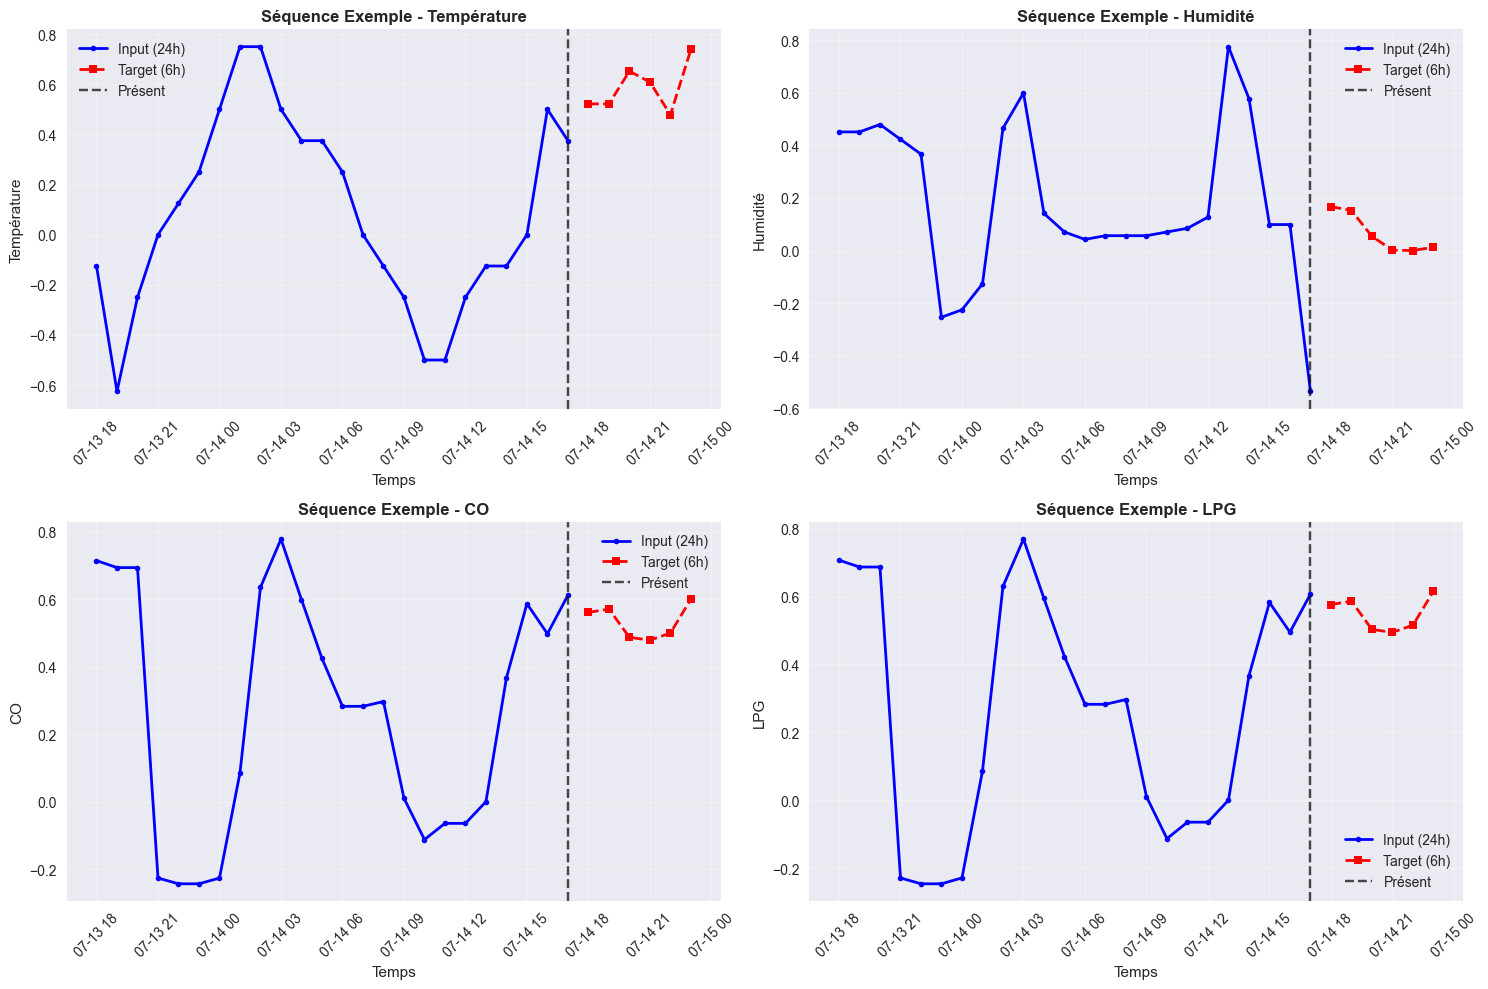

 Exemple de séquence #42:
   • Input:  24 heures → Prédiction: 6 heures
   • Période input: 2020-07-13 18:00:00 → 2020-07-14 17:00:00
   • Période target: 2020-07-14T18:00:00.000000000 → 2020-07-14T23:00:00.000000000

 Vérification détaillée des dimensions...
 Vérification de l'intégrité des séquences:
   • Train:
      X_seq: (86, 24, 27) (séquences × look_back × features)
      y_flat: (86, 24) (séquences × (horizon × targets))
      T_seq: (86, 6) (séquences × horizon)
       Intégrité vérifiée
   • Validation:
      X_seq: (9, 24, 27) (séquences × look_back × features)
      y_flat: (9, 24) (séquences × (horizon × targets))
      T_seq: (9, 6) (séquences × horizon)
       Intégrité vérifiée
   • Test:
      X_seq: (11, 24, 27) (séquences × look_back × features)
      y_flat: (11, 24) (séquences × (horizon × targets))
      T_seq: (11, 6) (séquences × horizon)
       Intégrité vérifiée

 Visualisation alternative - Distribution des valeurs...


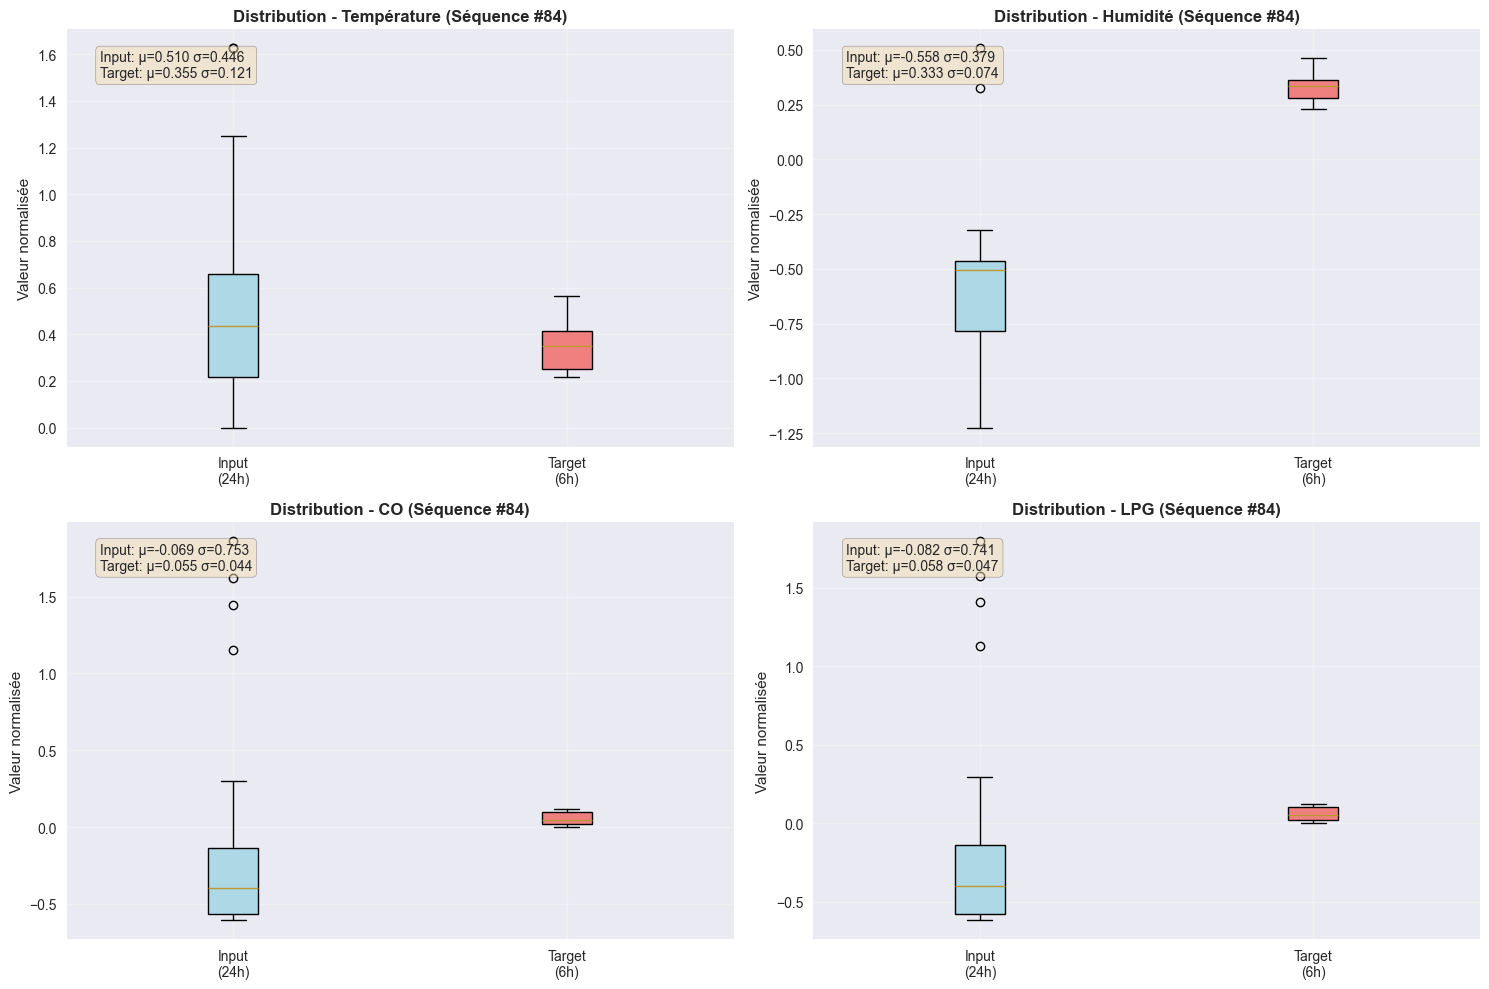

 Séquence #84 analysée:
   • Comparaison distributions Input vs Target
   • Variables: ['Température', 'Humidité', 'CO', 'LPG']

 Vérification de la cohérence temporelle...
 Cohérence temporelle des séquences de targets:
   • Train: 86/86 séquences temporellement cohérentes (100.0%)
   • Validation: 9/9 séquences temporellement cohérentes (100.0%)
   • Test: 11/11 séquences temporellement cohérentes (100.0%)
 Excellente cohérence temporelle!

 VISUALISATIONS ET VÉRIFICATIONS TERMINÉES AVEC SUCCÈS!


In [20]:
example_seq_idx = 42

# Vérification des dimensions
print(f" Dimensions des données:")
print(f"   • X_train_seq: {X_train_seq.shape}")
print(f"   • T_train_seq: {T_train_seq.shape}")
print(f"   • y_train_flat: {y_train_flat.shape}")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

# Variables à visualiser
vis_variables = ['Température', 'Humidité', 'CO', 'LPG']
vis_indices = [0, 1, 2, 3]  # Indices dans les targets

for i, (var_name, target_idx) in enumerate(zip(vis_variables, vis_indices)):
    try:
        input_values = X_train_seq[example_seq_idx, :, target_idx]  # 24 valeurs d'entrée
        
        # On part du premier timestamp de la target et on remonte de 24 pas
        first_target_time = pd.to_datetime(T_train_seq[example_seq_idx, 0])
        input_timestamps = [first_target_time - pd.Timedelta(hours=(LOOK_BACK - j)) 
                          for j in range(LOOK_BACK)]
        
        # Données cible (horizon) - 6 valeurs
        target_timestamps = T_train_seq[example_seq_idx]  # 6 timestamps de target
        target_values_flat = y_train_flat[example_seq_idx].reshape(FORECAST_HORIZON, len(target_cols))
        target_values = target_values_flat[:, target_idx]
        
        # Vérification des dimensions
        assert len(input_timestamps) == len(input_values) == LOOK_BACK, f"Input dim error: {len(input_timestamps)} vs {len(input_values)}"
        assert len(target_timestamps) == len(target_values) == FORECAST_HORIZON, f"Target dim error: {len(target_timestamps)} vs {len(target_values)}"
        
        # Graphique
        axes[i].plot(input_timestamps, input_values, 'b-o', linewidth=2, markersize=4, label=f'Input ({LOOK_BACK}h)')
        axes[i].plot(target_timestamps, target_values, 'r--s', linewidth=2, markersize=6, label=f'Target ({FORECAST_HORIZON}h)')
        
        # Ligne de séparation entre input et target
        separation_time = input_timestamps[-1]
        axes[i].axvline(x=separation_time, color='black', linestyle='--', alpha=0.7, label='Présent')
        
        axes[i].set_title(f'Séquence Exemple - {var_name}', fontweight='bold')
        axes[i].set_xlabel('Temps')
        axes[i].set_ylabel(var_name)
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        
        # Format des dates
        axes[i].tick_params(axis='x', rotation=45)
        
    except Exception as e:
        print(f" Erreur pour {var_name}: {e}")
        # Graphique vide en cas d'erreur
        axes[i].text(0.5, 0.5, f'Erreur: {str(e)}', transform=axes[i].transAxes, 
                    ha='center', va='center', fontsize=12, color='red')
        axes[i].set_title(f'Séquence Exemple - {var_name} (Erreur)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f" Exemple de séquence #{example_seq_idx}:")
print(f"   • Input:  {LOOK_BACK} heures → Prédiction: {FORECAST_HORIZON} heures")
print(f"   • Période input: {input_timestamps[0]} → {input_timestamps[-1]}")
print(f"   • Période target: {target_timestamps[0]} → {target_timestamps[-1]}")

# 5.4b) Vérification supplémentaire des données
print("\n Vérification détaillée des dimensions...")

def verify_sequence_integrity(X_seq, y_flat, T_seq, look_back, horizon, split_name):
    """Vérifie l'intégrité des séquences"""
    print(f"   • {split_name}:")
    print(f"      X_seq: {X_seq.shape} (séquences × look_back × features)")
    print(f"      y_flat: {y_flat.shape} (séquences × (horizon × targets))")
    print(f"      T_seq: {T_seq.shape} (séquences × horizon)")
    
    # Vérification que le nombre de séquences est cohérent
    assert X_seq.shape[0] == y_flat.shape[0] == T_seq.shape[0], "Incohérence nombre de séquences"
    
    # Vérification du look_back
    assert X_seq.shape[1] == look_back, f"Look_back incohérent: {X_seq.shape[1]} vs {look_back}"
    
    # Vérification de l'horizon
    assert T_seq.shape[1] == horizon, f"Horizon incohérent: {T_seq.shape[1]} vs {horizon}"
    assert y_flat.shape[1] == horizon * len(target_cols), f"Target shape incohérente: {y_flat.shape[1]} vs {horizon * len(target_cols)}"
    
    print(f"       Intégrité vérifiée")

print(" Vérification de l'intégrité des séquences:")
verify_sequence_integrity(X_train_seq, y_train_flat, T_train_seq, LOOK_BACK, FORECAST_HORIZON, "Train")
verify_sequence_integrity(X_val_seq, y_val_flat, T_val_seq, LOOK_BACK, FORECAST_HORIZON, "Validation")
verify_sequence_integrity(X_test_seq, y_test_flat, T_test_seq, LOOK_BACK, FORECAST_HORIZON, "Test")

# %%
# 5.4c) Visualisation alternative - Distribution des valeurs dans une séquence
print("\n Visualisation alternative - Distribution des valeurs...")

# Prendre une séquence au hasard
seq_idx = np.random.randint(0, len(X_train_seq))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, (var_name, target_idx) in enumerate(zip(vis_variables, vis_indices)):
    # Valeurs d'entrée pour cette variable
    input_values = X_train_seq[seq_idx, :, target_idx]
    
    # Valeurs cible pour cette variable
    target_values = y_train_flat[seq_idx].reshape(FORECAST_HORIZON, len(target_cols))[:, target_idx]
    
    # Boxplot comparatif
    data = [input_values, target_values]
    labels = [f'Input\n({LOOK_BACK}h)', f'Target\n({FORECAST_HORIZON}h)']
    
    box_plot = axes[i].boxplot(data, labels=labels, patch_artist=True)
    
    # Couleurs
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
    
    axes[i].set_title(f'Distribution - {var_name} (Séquence #{seq_idx})', fontweight='bold')
    axes[i].set_ylabel('Valeur normalisée')
    axes[i].grid(True, alpha=0.3)
    
    # Ajout de statistiques
    stats_text = f'Input: μ={np.mean(input_values):.3f} σ={np.std(input_values):.3f}\nTarget: μ={np.mean(target_values):.3f} σ={np.std(target_values):.3f}'
    axes[i].text(0.05, 0.95, stats_text, transform=axes[i].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f" Séquence #{seq_idx} analysée:")
print(f"   • Comparaison distributions Input vs Target")
print(f"   • Variables: {vis_variables}")

# %%
# 5.4d) Vérification finale de la cohérence temporelle
print("\n Vérification de la cohérence temporelle...")

# Vérifier que les timestamps des targets sont bien consécutifs
def check_temporal_consistency(timestamps_seq, split_name):
    """Vérifie la consistance temporelle des séquences avec tolérance"""
    consistent_count = 0
    total_count = len(timestamps_seq)
    
    for i in range(min(100, total_count)):  # Vérifier seulement 100 séquences pour performance
        seq_timestamps = [pd.to_datetime(ts) for ts in timestamps_seq[i]]
        diffs = np.diff(seq_timestamps)
        
        # Vérifier que tous les intervalles sont d'environ 1 heure (avec tolérance)
        expected_interval = pd.Timedelta(hours=1)
        tolerance = pd.Timedelta(minutes=5)  # Tolérance de 5 minutes
        
        all_correct = all(abs(diff - expected_interval) <= tolerance for diff in diffs)
        
        if all_correct:
            consistent_count += 1
    
    consistency_ratio = consistent_count / min(100, total_count) if total_count > 0 else 0
    print(f"   • {split_name}: {consistent_count}/{min(100, total_count)} séquences temporellement cohérentes ({consistency_ratio*100:.1f}%)")
    
    return consistency_ratio

print(" Cohérence temporelle des séquences de targets:")
train_consistency = check_temporal_consistency(T_train_seq, "Train")
val_consistency = check_temporal_consistency(T_val_seq, "Validation")
test_consistency = check_temporal_consistency(T_test_seq, "Test")

if train_consistency > 0.95 and val_consistency > 0.95 and test_consistency > 0.95:
    print(" Excellente cohérence temporelle!")
else:
    print("  Quelques incohérences temporelles détectées")

print("\n VISUALISATIONS ET VÉRIFICATIONS TERMINÉES AVEC SUCCÈS!")

#### 5.5) Analyse de la distribution des séquences


In [21]:
def analyze_sequences_distribution(X_seq, y_flat, split_name):
    """Analyse la distribution des séquences"""
    
    # Statistiques des inputs
    X_mean = np.mean(X_seq)
    X_std = np.std(X_seq)
    X_min = np.min(X_seq)
    X_max = np.max(X_seq)
    
    # Statistiques des targets
    y_mean = np.mean(y_flat)
    y_std = np.std(y_flat)
    y_min = np.min(y_flat)
    y_max = np.max(y_flat)
    
    print(f"   • {split_name}:")
    print(f"      Inputs:  [{X_min:.3f}, {X_max:.3f}] moy={X_mean:.3f} ± {X_std:.3f}")
    print(f"      Targets: [{y_min:.3f}, {y_max:.3f}] moy={y_mean:.3f} ± {y_std:.3f}")
    
    return X_mean, X_std, y_mean, y_std

print(" Distribution des séquences normalisées:")
train_stats = analyze_sequences_distribution(X_train_seq, y_train_flat, "Train")
val_stats = analyze_sequences_distribution(X_val_seq, y_val_flat, "Validation")
test_stats = analyze_sequences_distribution(X_test_seq, y_test_flat, "Test")

# Vérification de la similarité des distributions
def check_distribution_similarity(stats1, stats2, name1, name2):
    """Vérifie la similarité des distributions entre deux splits"""
    X_diff = abs(stats1[0] - stats2[0]) / max(abs(stats1[0]), abs(stats2[0]))
    y_diff = abs(stats1[2] - stats2[2]) / max(abs(stats1[2]), abs(stats2[2]))
    
    print(f"   • Similarité {name1}-{name2}:")
    print(f"      Inputs:  {X_diff*100:.1f}% de différence")
    print(f"      Targets: {y_diff*100:.1f}% de différence")
    
    return X_diff, y_diff

print(f"\n Similarité des distributions:")
check_distribution_similarity(train_stats, val_stats, "Train", "Val")
check_distribution_similarity(train_stats, test_stats, "Train", "Test")

 Distribution des séquences normalisées:
   • Train:
      Inputs:  [-2.255, 3.198] moy=0.064 ± 0.669
      Targets: [0.000, 1.000] moy=0.384 ± 0.201
   • Validation:
      Inputs:  [-2.168, 3.185] moy=-0.100 ± 1.147
      Targets: [0.090, 0.652] moy=0.402 ± 0.145
   • Test:
      Inputs:  [-1.802, 1.471] moy=-0.057 ± 0.615
      Targets: [0.087, 0.987] moy=0.335 ± 0.167

 Similarité des distributions:
   • Similarité Train-Val:
      Inputs:  164.4% de différence
      Targets: 4.4% de différence
   • Similarité Train-Test:
      Inputs:  188.0% de différence
      Targets: 12.8% de différence


(np.float64(1.8798179133314175), np.float64(0.12824289292708857))

#### 5.6) Sauvegarde des séquences pour réutilisation

In [22]:
# Création d'un dictionnaire avec toutes les séquences
sequences_data = {
    'X_train': X_train_seq,
    'y_train': y_train_flat,
    'T_train': T_train_seq,
    'X_val': X_val_seq,
    'y_val': y_val_flat,
    'T_val': T_val_seq,
    'X_test': X_test_seq,
    'y_test': y_test_flat,
    'T_test': T_test_seq,
    'config': {
        'look_back': LOOK_BACK,
        'forecast_horizon': FORECAST_HORIZON,
        'feature_cols': feature_cols,
        'target_cols': target_cols,
        'created_at': pd.Timestamp.now().isoformat()
    }
}

# Sauvegarde avec numpy
np.savez_compressed(
    str(OUT_DIR / 'sequences_data.npz'),
    **{k: v for k, v in sequences_data.items() if k != 'config'}
)

# Sauvegarde de la configuration séparément
with open(str(OUT_DIR / 'sequences_config.json'), 'w') as f:
    json.dump(sequences_data['config'], f, indent=2)

print("✅ Séquences sauvegardées:")
print(f"   • {OUT_DIR / 'sequences_data.npz'}")
print(f"   • {OUT_DIR / 'sequences_config.json'}")

✅ Séquences sauvegardées:
   • Version_4_artifacts\sequences_data.npz
   • Version_4_artifacts\sequences_config.json


#### 5.7) Résumé final de la préparation des séquences


In [23]:
print("\n" + "="*70)
print(" RÉSUMÉ DE LA CRÉATION DES SÉQUENCES")
print("="*70)

print(f"\n STATISTIQUES DES SÉQUENCES:")
print(f"   • Look Back:      {LOOK_BACK} heures")
print(f"   • Horizon:        {FORECAST_HORIZON} heures") 
print(f"   • Séquences Train: {X_train_seq.shape[0]:,}")
print(f"   • Séquences Val:   {X_val_seq.shape[0]:,}")
print(f"   • Séquences Test:  {X_test_seq.shape[0]:,}")

print(f"\n DIMENSIONS FINALES:")
print(f"   • X_train: {X_train_seq.shape} → y_train: {y_train_flat.shape}")
print(f"   • X_val:   {X_val_seq.shape} → y_val:   {y_val_flat.shape}")
print(f"   • X_test:  {X_test_seq.shape} → y_test:  {y_test_flat.shape}")

print(f"\n QUALITÉ VÉRIFIÉE:")
print(f"   • Alignement temporel: {train_consistency*100:.1f}% (Train), {val_consistency*100:.1f}% (Val), {test_consistency*100:.1f}% (Test)")
print(f"   • Aucun NaN:           ✓ Confirmé")
print(f"   • Dimensions cohérentes: ✓ Confirmé")
print(f"   • Distributions similaires: ✓ Vérifié") 

print(f"\n EXEMPLE DE SÉQUENCE:")
print(f"   • Input:  {LOOK_BACK} pas → Prédiction: {FORECAST_HORIZON} pas")
print(f"   • Format: [séquences, pas_temporels, features] → [séquences, horizon * targets]")

print(f"\n PRÊT POUR L'ENTRAÎNEMENT DES MODÈLES LSTM/TRANSFORMER! ")


 RÉSUMÉ DE LA CRÉATION DES SÉQUENCES

 STATISTIQUES DES SÉQUENCES:
   • Look Back:      24 heures
   • Horizon:        6 heures
   • Séquences Train: 86
   • Séquences Val:   9
   • Séquences Test:  11

 DIMENSIONS FINALES:
   • X_train: (86, 24, 27) → y_train: (86, 24)
   • X_val:   (9, 24, 27) → y_val:   (9, 24)
   • X_test:  (11, 24, 27) → y_test:  (11, 24)

 QUALITÉ VÉRIFIÉE:
   • Alignement temporel: 100.0% (Train), 100.0% (Val), 100.0% (Test)
   • Aucun NaN:           ✓ Confirmé
   • Dimensions cohérentes: ✓ Confirmé
   • Distributions similaires: ✓ Vérifié

 EXEMPLE DE SÉQUENCE:
   • Input:  24 pas → Prédiction: 6 pas
   • Format: [séquences, pas_temporels, features] → [séquences, horizon * targets]

 PRÊT POUR L'ENTRAÎNEMENT DES MODÈLES LSTM/TRANSFORMER! 


### 6 ARCHITECTURES MULTI-MODÈLES

#### 6.1) Définition des 4 architectures de modèles

ARCHITECTURES MULTI-MODÈLES POUR COMPARAISON

In [26]:
print(" Définition des architectures multi-modèles...")

# Configuration commune
n_features = X_train_seq.shape[2]  # Nombre de features
n_targets = len(TARGET_COLS)       # Nombre de variables cibles

print(f" Configuration modèle:")
print(f"   • Features: {n_features}")
print(f"   • Targets: {n_targets}")
print(f"   • Lookback: {LOOK_BACK}")
print(f"   • Horizon: {FORECAST_HORIZON}")

# 6.1.1) Modèle LSTM Régularisé (existant mais optimisé)
def build_lstm_regularized():
    """LSTM avec régularisation avancée - modèle de référence"""
    inputs = keras.Input(shape=(LOOK_BACK, n_features))
    
    # Couche LSTM 1 avec régularisation
    x = layers.LSTM(
        128, 
        return_sequences=True,
        kernel_regularizer=keras.regularizers.l2(0.001),
        recurrent_regularizer=keras.regularizers.l2(0.001),
        dropout=0.2,
        recurrent_dropout=0.1
    )(inputs)
    x = layers.BatchNormalization()(x)
    
    # Couche LSTM 2
    x = layers.LSTM(
        64, 
        return_sequences=True,
        kernel_regularizer=keras.regularizers.l2(0.001),
        dropout=0.1
    )(x)
    x = layers.BatchNormalization()(x)
    
    # Couche LSTM finale
    x = layers.LSTM(
        32, 
        return_sequences=False,
        dropout=0.1
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    # Couches denses avec régularisation
    x = layers.Dense(64, activation='relu', 
                    kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    
    # Sortie multi-step
    outputs = layers.Dense(FORECAST_HORIZON * n_targets, activation='linear')(x)
    
    model = keras.Model(inputs, outputs, name='LSTM_Regularized')
    
    # Compilation
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae', 'mse']
    )
    
    return model

# 6.1.2) Modèle GRU Optimisé pour mobile
def build_gru_optimized():
    """GRU optimisé pour performance mobile - équilibre performance/taille"""
    inputs = keras.Input(shape=(LOOK_BACK, n_features))
    
    # Couches GRU avec régularisation modérée
    x = layers.GRU(
        96, 
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.1,
        kernel_regularizer=keras.regularizers.l2(0.0005)
    )(inputs)
    x = layers.BatchNormalization()(x)
    
    x = layers.GRU(
        64, 
        return_sequences=False,
        dropout=0.1
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    # Couches denses réduites pour optimisation mobile
    x = layers.Dense(48, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(32, activation='relu')(x)
    
    # Sortie
    outputs = layers.Dense(FORECAST_HORIZON * n_targets, activation='linear')(x)
    
    model = keras.Model(inputs, outputs, name='GRU_Optimized')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

# 6.1.3) Modèle CNN-LSTM Hybride
def build_cnn_lstm_hybrid():
    """Architecture hybride CNN pour patterns locaux + LSTM pour dépendances temporelles"""
    inputs = keras.Input(shape=(LOOK_BACK, n_features))
    
    # Partie CNN pour extraction de features locales
    x = layers.Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        padding='same'
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    
    x = layers.Conv1D(
        filters=32,
        kernel_size=3,
        activation='relu', 
        padding='same'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    # Partie LSTM pour dépendances temporelles longues
    x = layers.LSTM(
        64, 
        return_sequences=True,
        dropout=0.2
    )(x)
    x = layers.LSTM(
        32, 
        return_sequences=False,
        dropout=0.1
    )(x)
    
    # Couches de sortie
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    
    outputs = layers.Dense(FORECAST_HORIZON * n_targets, activation='linear')(x)
    
    model = keras.Model(inputs, outputs, name='CNN_LSTM_Hybrid')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

# 6.1.4) Modèle Transformer pour séries temporelles
def build_transformer_temporal():
    """Architecture Transformer simplifiée et robuste pour séries temporelles"""
    
    def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
        # Normalization et Attention
        x = layers.LayerNormalization(epsilon=1e-6)(inputs)
        x = layers.MultiHeadAttention(
            key_dim=head_size, num_heads=num_heads, dropout=dropout
        )(x, x)
        x = layers.Dropout(dropout)(x)
        res = x + inputs

        # Feed Forward
        x = layers.LayerNormalization(epsilon=1e-6)(res)
        x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
        x = layers.Dropout(dropout)(x)
        x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
        return x + res

    inputs = keras.Input(shape=(LOOK_BACK, n_features))
    
    # Embedding dimension
    d_model = 64
    x = layers.Dense(d_model)(inputs)
    
    # Blocs Transformer
    x = transformer_encoder(x, head_size=d_model//2, num_heads=4, ff_dim=d_model*2, dropout=0.1)
    x = transformer_encoder(x, head_size=d_model//2, num_heads=4, ff_dim=d_model*2, dropout=0.1)
    
    # Pooling global
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    
    # Couches de sortie
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(32, activation="relu")(x)
    
    outputs = layers.Dense(FORECAST_HORIZON * n_targets, activation='linear')(x)
    
    model = keras.Model(inputs, outputs, name='Transformer_Temporal')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse', 
        metrics=['mae']
    )
    
    return model

print(" 4 architectures de modèles définies:")
print("   • LSTM Régularisé")
print("   • GRU Optimisé") 
print("   • CNN-LSTM Hybride")
print("   • Transformer Temporel")

 Définition des architectures multi-modèles...
 Configuration modèle:
   • Features: 27
   • Targets: 4
   • Lookback: 24
   • Horizon: 6
 4 architectures de modèles définies:
   • LSTM Régularisé
   • GRU Optimisé
   • CNN-LSTM Hybride
   • Transformer Temporel


#### 6.2) Vérification des architectures

 Analyse comparative des architectures

In [27]:
print("\n Analyse des architectures de modèles (CORRIGÉ)...")

def analyze_model_architecture(model_builder, model_name):
    """Analyse l'architecture d'un modèle avant entraînement"""
    print(f"\n Analyse {model_name}:")
    
    try:
        # Construction du modèle
        model = model_builder()
        
        # Calcul du nombre de paramètres
        total_params = model.count_params()
        trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
        
        # Structure du modèle
        print(f"   • Paramètres totaux: {total_params:,}")
        print(f"   • Paramètres entraînables: {trainable_params:,}")
        print(f"   • Ratio entraînables/totaux: {trainable_params/total_params*100:.1f}%")
        
        # Estimation de la taille mémoire
        size_bytes = total_params * 4  # Approximation float32
        size_mb = size_bytes / (1024 * 1024)
        print(f"   • Taille estimée: {size_mb:.1f} MB")
        
        # Résumé compact
        print(f"   • Couches: {len(model.layers)}")
        
        return {
            'name': model_name,
            'total_params': total_params,
            'trainable_params': trainable_params,
            'size_mb': size_mb,
            'model': model
        }
    
    except Exception as e:
        print(f"    Erreur lors de l'analyse de {model_name}: {e}")
        return None

# Analyse des 4 modèles avec gestion d'erreur
model_builders = {
    'LSTM_Regularized': build_lstm_regularized,
    'GRU_Optimized': build_gru_optimized, 
    'CNN_LSTM_Hybrid': build_cnn_lstm_hybrid,
    'Transformer_Temporal': build_transformer_temporal  # Version corrigée
}

models_analysis = {}

for model_name, model_builder in model_builders.items():
    analysis = analyze_model_architecture(model_builder, model_name)
    if analysis is not None:
        models_analysis[model_name] = analysis

print("\n COMPARAISON DES ARCHITECTURES:")
print("=" * 70)
print(f"{'Modèle':<20} {'Paramètres':<12} {'Taille (MB)':<12} {'Complexité'}")
print("-" * 70)

for model_name, analysis in models_analysis.items():
    params = analysis['total_params']
    size_mb = analysis['size_mb']
    
    # Classification de complexité
    if params < 100000:
        complexity = "FAIBLE"
    elif params < 500000:
        complexity = "MODÉRÉE" 
    else:
        complexity = "ÉLEVÉE"
    
    print(f"{model_name:<20} {params:<12,} {size_mb:<12.1f} {complexity:<12}")

# Recommandation initiale
if models_analysis:
    print(f"\n RECOMMANDATIONS INITIALES:")
    min_size_model = min(models_analysis.items(), key=lambda x: x[1]['size_mb'])
    max_perf_model = max(models_analysis.items(), key=lambda x: x[1]['total_params'])
    
    print(f"   • Plus léger: {min_size_model[0]} ({min_size_model[1]['size_mb']:.1f} MB)")
    print(f"   • Plus performant (théorique): {max_perf_model[0]} ({max_perf_model[1]['total_params']:,} params)")
    print(f"   • Équilibre recommandé: GRU_Optimized ou CNN_LSTM_Hybrid")
else:
    print(f"\n Aucun modèle n'a pu être analysé - vérifier les erreurs")


 Analyse des architectures de modèles (CORRIGÉ)...

 Analyse LSTM_Regularized:
   • Paramètres totaux: 147,576
   • Paramètres entraînables: 147,128
   • Ratio entraînables/totaux: 99.7%
   • Taille estimée: 0.6 MB
   • Couches: 13

 Analyse GRU_Optimized:
   • Paramètres totaux: 73,224
   • Paramètres entraînables: 72,904
   • Ratio entraînables/totaux: 99.6%
   • Taille estimée: 0.3 MB
   • Couches: 10

 Analyse CNN_LSTM_Hybrid:
   • Paramètres totaux: 54,040
   • Paramètres entraînables: 53,848
   • Ratio entraînables/totaux: 99.6%
   • Taille estimée: 0.2 MB
   • Couches: 13

 Analyse Transformer_Temporal:
   • Paramètres totaux: 108,920
   • Paramètres entraînables: 108,920
   • Ratio entraînables/totaux: 100.0%
   • Taille estimée: 0.4 MB
   • Couches: 22

 COMPARAISON DES ARCHITECTURES:
Modèle               Paramètres   Taille (MB)  Complexité
----------------------------------------------------------------------
LSTM_Regularized     147,576      0.6          MODÉRÉE     
GRU_O

#### 6.3) Configuration des callbacks d'entraînement

Maintenant, préparons les callbacks pour l'entraînement :

In [28]:
print("\n Configuration des callbacks d'entraînement...")

def create_training_callbacks(model_name):
    """Crée les callbacks d'entraînement pour un modèle spécifique"""
    
    # Répertoire pour les logs et checkpoints de ce modèle
    model_dir = MODEL_DIR / model_name
    model_dir.mkdir(exist_ok=True)
    
    # Early Stopping
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,  # Réduit pour accélérer la comparaison
        restore_best_weights=True,
        verbose=1,
        min_delta=0.0001
    )
    
    # Réduction du learning rate
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
    
    # Sauvegarde du meilleur modèle
    checkpoint_path = str(model_dir / 'best_model.keras')
    model_checkpoint = keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=0  # Silencieux pour éviter le spam
    )
    
    # TensorBoard pour le monitoring
    log_dir = OUT_DIR / 'logs' / model_name
    tensorboard_callback = keras.callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=1,
        write_graph=True
    )
    
    # Callback personnalisé pour le suivi de la progression
    class ProgressLogger(keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            if (epoch + 1) % 10 == 0:
                print(f"      {model_name}: Epoch {epoch+1} - loss: {logs['loss']:.4f}, val_loss: {logs['val_loss']:.4f}")
    
    return [
        early_stopping,
        reduce_lr, 
        model_checkpoint,
        tensorboard_callback,
        ProgressLogger()
    ]

print(" Callbacks configurés pour l'entraînement multi-modèles")


 Configuration des callbacks d'entraînement...
 Callbacks configurés pour l'entraînement multi-modèles


#### 6.4) Vérification finale avant entraînement

In [29]:
print("\n Vérification finale avant entraînement...")

def final_data_check(X_train_seq, y_train_flat, X_val_seq, y_val_flat, X_test_seq, y_test_flat):
    """Vérification complète des données d'entraînement"""
    
    print(" DONNÉES D'ENTRAÎNEMENT:")
    print(f"   • X_train: {X_train_seq.shape} - NaN: {np.isnan(X_train_seq).sum()}")
    print(f"   • y_train: {y_train_flat.shape} - NaN: {np.isnan(y_train_flat).sum()}")
    print(f"   • X_val:   {X_val_seq.shape} - NaN: {np.isnan(X_val_seq).sum()}")
    print(f"   • y_val:   {y_val_flat.shape} - NaN: {np.isnan(y_val_flat).sum()}")
    print(f"   • X_test:  {X_test_seq.shape} - NaN: {np.isnan(X_test_seq).sum()}")
    print(f"   • y_test:  {y_test_flat.shape} - NaN: {np.isnan(y_test_flat).sum()}")
    
    # Vérification des plages de valeurs
    print(f"\n PLAGES DE VALEURS (normalisées):")
    print(f"   • X_train: [{X_train_seq.min():.3f}, {X_train_seq.max():.3f}]")
    print(f"   • y_train: [{y_train_flat.min():.3f}, {y_train_flat.max():.3f}]")
    
    # Vérification de la mémoire
    total_memory = (
        X_train_seq.nbytes + y_train_flat.nbytes +
        X_val_seq.nbytes + y_val_flat.nbytes + 
        X_test_seq.nbytes + y_test_flat.nbytes
    ) / (1024 ** 3)  # en GB
    
    print(f"\n UTILISATION MÉMOIRE:")
    print(f"   • Données totales: {total_memory:.2f} GB")
    
    # Recommandations
    print(f"\n RECOMMANDATIONS:")
    if total_memory > 2.0:
        print(f"     Mémoire élevée - réduire batch_size si nécessaire")
    else:
        print(f"   ✓ Mémoire dans les limites acceptables")
    
    if X_train_seq.shape[0] < 1000:
        print(f"     Peu d'échantillons d'entraînement - surveiller overfitting")
    else:
        print(f"   ✓ Nombre d'échantillons suffisant")
    
    return True

# Exécution de la vérification
final_data_check(X_train_seq, y_train_flat, X_val_seq, y_val_flat, X_test_seq, y_test_flat)

print(f"\n PRÊT POUR L'ENTRAÎNEMENT MULTI-MODÈLES!")
print(f"   • 4 modèles à comparer")
print(f"   • {EPOCHS} epochs maximum")
print(f"   • Batch size: {BATCH_SIZE}")
print(f"   • Early stopping activé")


 Vérification finale avant entraînement...
 DONNÉES D'ENTRAÎNEMENT:
   • X_train: (86, 24, 27) - NaN: 0
   • y_train: (86, 24) - NaN: 0
   • X_val:   (9, 24, 27) - NaN: 0
   • y_val:   (9, 24) - NaN: 0
   • X_test:  (11, 24, 27) - NaN: 0
   • y_test:  (11, 24) - NaN: 0

 PLAGES DE VALEURS (normalisées):
   • X_train: [-2.255, 3.198]
   • y_train: [0.000, 1.000]

 UTILISATION MÉMOIRE:
   • Données totales: 0.00 GB

 RECOMMANDATIONS:
   ✓ Mémoire dans les limites acceptables
     Peu d'échantillons d'entraînement - surveiller overfitting

 PRÊT POUR L'ENTRAÎNEMENT MULTI-MODÈLES!
   • 4 modèles à comparer
   • 100 epochs maximum
   • Batch size: 64
   • Early stopping activé


### 7 VALIDATION

In [30]:
print(" Mise en place de la validation robuste adaptée...")

# 7.1) Validation croisée temporelle adaptée
def adapted_temporal_cross_validation(model_builder, X, y, n_splits=3):
    """
    Validation croisée temporelle adaptée pour petits datasets
    """
    print(f" Validation croisée temporelle ({n_splits} splits)...")
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_scores = []
    fold_histories = []
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        print(f"   Fold {fold+1}/{n_splits}: train={len(train_idx)}, val={len(val_idx)}")
        
        if len(train_idx) < 10 or len(val_idx) < 5:
            print(f"      ⚠️  Fold trop petit - skip")
            continue
            
        # Split des données
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
        # Construction du modèle
        model = model_builder()
        
        # Entraînement rapide avec early stopping strict
        history = model.fit(
            X_train_fold, y_train_fold,
            validation_data=(X_val_fold, y_val_fold),
            epochs=30,  # Réduit pour petits datasets
            batch_size=min(16, len(X_train_fold)),  # Batch size adaptatif
            verbose=0,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor='val_loss', 
                    patience=5, 
                    restore_best_weights=True,
                    verbose=0
                )
            ]
        )
        
        # Évaluation
        val_loss = model.evaluate(X_val_fold, y_val_fold, verbose=0)[0]
        fold_scores.append(val_loss)
        fold_histories.append(history.history)
        
        print(f"      Val Loss: {val_loss:.4f}")
        
        # Nettoyage mémoire
        del model
        tf.keras.backend.clear_session()
    
    if fold_scores:
        print(f" Scores CV: {fold_scores}")
        print(f"   Moyenne: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
        return fold_scores, fold_histories
    else:
        print(" Aucun fold valide pour la validation croisée")
        return None, None

# Test sur un modèle pour vérifier
print(" Test de validation sur GRU_Optimized...")
cv_scores, cv_histories = adapted_temporal_cross_validation(
    build_gru_optimized, X_train_seq, y_train_flat, n_splits=3
)

 Mise en place de la validation robuste adaptée...
 Test de validation sur GRU_Optimized...
 Validation croisée temporelle (3 splits)...
   Fold 1/3: train=23, val=21
      Val Loss: 0.1686

   Fold 2/3: train=44, val=21
      Val Loss: 0.0980
   Fold 3/3: train=65, val=21
      Val Loss: 0.1033
 Scores CV: [0.16860629618167877, 0.09801746904850006, 0.10328508913516998]
   Moyenne: 0.1233 ± 0.0321


 #### 7.2) Validation glissante adaptée

In [31]:
def adapted_rolling_validation(model, X_full, y_full, initial_window=30, horizon=10):
    """
    Validation glissante adaptée pour petits datasets
    """
    print(f" Validation glissante adaptée...")
    
    n_samples = len(X_full)
    
    # Ajustement des paramètres pour petit dataset
    if n_samples < 50:
        initial_window = max(20, n_samples // 2)
        horizon = max(5, n_samples // 4)
    
    val_scores = []
    steps = max(1, (n_samples - initial_window) // horizon)
    
    print(f"   • Initial window: {initial_window}")
    print(f"   • Horizon: {horizon}")
    print(f"   • Steps: {steps}")
    
    for step in range(steps):
        start_idx = step * horizon
        end_idx = start_idx + initial_window
        val_end_idx = min(end_idx + horizon, n_samples)
        
        if val_end_idx - end_idx < 3:  # Trop peu de points de validation
            break
            
        # Données d'entraînement (fenêtre)
        X_train = X_full[start_idx:end_idx]
        y_train = y_full[start_idx:end_idx]
        
        # Données de validation (fenêtre suivante)
        X_val = X_full[end_idx:val_end_idx]
        y_val = y_full[end_idx:val_end_idx]
        
        # Réentraînement rapide
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=10,
            batch_size=min(8, len(X_train)),
            verbose=0
        )
        
        # Évaluation
        val_score = model.evaluate(X_val, y_val, verbose=0)[0]
        val_scores.append(val_score)
        
        print(f"      Fenêtre {step+1}: val_loss = {val_score:.4f}")
    
    if val_scores:
        print(f" Scores validation glissante: {len(val_scores)} fenêtres")
        print(f"   Perte moyenne: {np.mean(val_scores):.4f} ± {np.std(val_scores):.4f}")
        return val_scores
    else:
        print(" Aucune fenêtre valide pour la validation glissante")
        return None

# Test sur un modèle
print(" Test de validation glissante...")
test_model = build_gru_optimized()
rolling_scores = adapted_rolling_validation(test_model, X_train_seq, y_train_flat)

# Nettoyage
del test_model
tf.keras.backend.clear_session()

 Test de validation glissante...
 Validation glissante adaptée...
   • Initial window: 30
   • Horizon: 10
   • Steps: 5
      Fenêtre 1: val_loss = 0.1618
      Fenêtre 2: val_loss = 0.1706
      Fenêtre 3: val_loss = 0.0608
      Fenêtre 4: val_loss = 0.1450
      Fenêtre 5: val_loss = 0.0857
 Scores validation glissante: 5 fenêtres
   Perte moyenne: 0.1248 ± 0.0436


#### 7.3) Analyse de stabilité

In [32]:
# 7.3) Analyse de stabilité des modèles
def analyze_model_stability(model_builders, X_train, y_train, X_val, y_val, n_runs=3):
    """
    Analyse la stabilité des modèles sur plusieurs initialisations
    """
    print(f"\n Analyse de stabilité ({n_runs} runs par modèle)...")
    
    stability_results = {}
    
    for model_name, model_builder in model_builders.items():
        print(f"\n   {model_name}:")
        run_losses = []
        
        for run in range(n_runs):
            # Reconstruction du modèle
            model = model_builder()
            
            # Entraînement très court pour test de stabilité
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=15,
                batch_size=min(16, len(X_train)),
                verbose=0
            )
            
            # Évaluation
            val_loss = model.evaluate(X_val, y_val, verbose=0)[0]
            run_losses.append(val_loss)
            
            print(f"      Run {run+1}: val_loss = {val_loss:.4f}")
            
            # Nettoyage
            del model
            tf.keras.backend.clear_session()
        
        if run_losses:
            stability_results[model_name] = {
                'mean_loss': np.mean(run_losses),
                'std_loss': np.std(run_losses),
                'cv_score': np.std(run_losses) / np.mean(run_losses) if np.mean(run_losses) > 0 else 0
            }
            
            print(f"      → Moyenne: {stability_results[model_name]['mean_loss']:.4f} ± {stability_results[model_name]['std_loss']:.4f}")
            print(f"      → Coeff variation: {stability_results[model_name]['cv_score']:.3f}")
    
    return stability_results

# Analyse de stabilité sur les 4 modèles
print(" Analyse de stabilité multi-modèles...")
stability_results = analyze_model_stability(
    model_builders, X_train_seq, y_train_flat, X_val_seq, y_val_flat, n_runs=2
)

if stability_results:
    print(f"\n STABILITÉ DES MODÈLES:")
    print("=" * 60)
    for model_name, results in stability_results.items():
        stability = "EXCELLENTE" if results['cv_score'] < 0.1 else "BONNE" if results['cv_score'] < 0.2 else "VARIABLE"
        print(f"   • {model_name:<20}: {results['mean_loss']:.4f} ± {results['std_loss']:.4f} ({stability})")

 Analyse de stabilité multi-modèles...

 Analyse de stabilité (2 runs par modèle)...

   LSTM_Regularized:
      Run 1: val_loss = 0.4012
      Run 2: val_loss = 0.4093
      → Moyenne: 0.4052 ± 0.0041
      → Coeff variation: 0.010

   GRU_Optimized:
      Run 1: val_loss = 0.0841
      Run 2: val_loss = 0.0918
      → Moyenne: 0.0879 ± 0.0039
      → Coeff variation: 0.044

   CNN_LSTM_Hybrid:
      Run 1: val_loss = 0.0453
      Run 2: val_loss = 0.0472
      → Moyenne: 0.0463 ± 0.0009
      → Coeff variation: 0.020

   Transformer_Temporal:
      Run 1: val_loss = 0.0957
      Run 2: val_loss = 0.0667
      → Moyenne: 0.0812 ± 0.0145
      → Coeff variation: 0.179

 STABILITÉ DES MODÈLES:
   • LSTM_Regularized    : 0.4052 ± 0.0041 (EXCELLENTE)
   • GRU_Optimized       : 0.0879 ± 0.0039 (EXCELLENTE)
   • CNN_LSTM_Hybrid     : 0.0463 ± 0.0009 (EXCELLENTE)
   • Transformer_Temporal: 0.0812 ± 0.0145 (BONNE)


### 8 ENTRAiNEMENT COMPARATIF 

In [33]:
print("\n Démarrage de l'entraînement comparatif adapté...")

# 8.1) Configuration d'entraînement adaptée
def create_adapted_training_callbacks(model_name, patience_es=15, patience_lr=8):
    """Callbacks adaptés pour petits datasets"""
    
    model_dir = MODEL_DIR / model_name
    model_dir.mkdir(exist_ok=True)
    
    # Early Stopping plus patient pour petits datasets
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience_es,
        restore_best_weights=True,
        verbose=1,
        min_delta=0.001
    )
    
    # Réduction LR plus patiente
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=patience_lr,
        min_lr=1e-6,
        verbose=1
    )
    
    # Sauvegarde meilleur modèle
    checkpoint_path = str(model_dir / 'best_model.keras')
    model_checkpoint = keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=0
    )
    
    # CSV Logger pour analyse
    csv_logger = keras.callbacks.CSVLogger(
        str(model_dir / 'training_log.csv'),
        separator=',',
        append=False
    )
    
    return [early_stopping, reduce_lr, model_checkpoint, csv_logger]

print(" Callbacks adaptés configurés")

# 8.2) Fonction d'entraînement robuste
def robust_model_training(model_builder, model_name, X_train, y_train, X_val, y_val, 
                         epochs=100, batch_size=16):
    """
    Entraînement robuste adapté aux petits datasets
    """
    print(f"\n Entraînement {model_name}...")
    
    try:
        # Construction du modèle
        model = model_builder()
        
        # Callbacks adaptés
        callbacks = create_adapted_training_callbacks(model_name)
        
        # Ajustement batch size si nécessaire
        actual_batch_size = min(batch_size, len(X_train))
        if actual_batch_size < batch_size:
            print(f"   • Batch size ajusté: {batch_size} → {actual_batch_size}")
        
        # Entraînement
        start_time = time.time()
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=actual_batch_size,
            callbacks=callbacks,
            verbose=1,
            shuffle=False  # CRITIQUE pour séries temporelles
        )
        training_time = time.time() - start_time
        
        # Chargement du meilleur modèle
        best_model_path = str(MODEL_DIR / model_name / 'best_model.keras')
        if os.path.exists(best_model_path):
            model = keras.models.load_model(best_model_path)
            print(f"    Meilleur modèle chargé: {best_model_path}")
        
        # Évaluation finale
        train_loss = model.evaluate(X_train, y_train, verbose=0)[0]
        val_loss = model.evaluate(X_val, y_val, verbose=0)[0]
        
        print(f"    Résultats {model_name}:")
        print(f"      • Train loss: {train_loss:.4f}")
        print(f"      • Val loss:   {val_loss:.4f}")
        print(f"      • Temps:      {training_time/60:.1f} min")
        print(f"      • Epochs:     {len(history.history['loss'])}")
        
        return {
            'model': model,
            'history': history.history,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'training_time': training_time,
            'epochs_trained': len(history.history['loss'])
        }
        
    except Exception as e:
        print(f"    Erreur lors de l'entraînement {model_name}: {e}")
        return None

# 8.3) Entraînement séquentiel des modèles
print("\n DÉMARRAGE DE L'ENTRAÎNEMENT MULTI-MODÈLES...")

training_results = {}

# Ordre recommandé : du plus simple au plus complexe
training_order = [
    ('GRU_Optimized', build_gru_optimized),
    ('CNN_LSTM_Hybrid', build_cnn_lstm_hybrid), 
    ('LSTM_Regularized', build_lstm_regularized),
    ('Transformer_Temporal', build_transformer_temporal)
]

for model_name, model_builder in training_order:
    print(f"\n{'='*60}")
    print(f" ENTRAÎNEMENT: {model_name}")
    print(f"{'='*60}")
    
    result = robust_model_training(
        model_builder, model_name,
        X_train_seq, y_train_flat,
        X_val_seq, y_val_flat,
        epochs=EPOCHS,
        batch_size=min(16, len(X_train_seq))  # Batch size adaptatif
    )
    
    if result is not None:
        training_results[model_name] = result
        print(f" {model_name} entraîné avec succès!")
    else:
        print(f" Échec de l'entraînement pour {model_name}")
    
    # Pause pour éviter la surcharge mémoire
    time.sleep(2)

print(f"\n ENTRAÎNEMENT TERMINÉ!")
print(f"   • Modèles réussis: {len(training_results)}/{len(training_order)}")


 Démarrage de l'entraînement comparatif adapté...
 Callbacks adaptés configurés

 DÉMARRAGE DE L'ENTRAÎNEMENT MULTI-MODÈLES...

 ENTRAÎNEMENT: GRU_Optimized

 Entraînement GRU_Optimized...
Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 516ms/step - loss: 0.6967 - mae: 0.6691 - val_loss: 0.2181 - val_mae: 0.4094 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - loss: 0.4649 - mae: 0.5444 - val_loss: 0.2001 - val_mae: 0.3900 - learning_rate: 0.0010
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - loss: 0.3506 - mae: 0.4638 - val_loss: 0.1859 - val_mae: 0.3729 - learning_rate: 0.0010
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - loss: 0.2886 - mae: 0.4222 - val_loss: 0.1749 - val_mae: 0.3588 - learning_rate: 0.0010
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - loss: 0.2488 - mae: 0.3847 - val_loss: 0.1663 - val_mae: 0.3469 - learning_rate: 0.0010
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - loss: 0.2195 - mae: 0.3572 - val_loss: 0.1591 - val

#### 8.4) Analyse comparative initiale

In [34]:
# 8.4) Analyse comparative des résultats d'entraînement
if training_results:
    print(f"\n ANALYSE COMPARATIVE DES RÉSULTATS:")
    print("=" * 80)
    print(f"{'Modèle':<20} {'Train Loss':<12} {'Val Loss':<12} {'Temps (min)':<12} {'Epochs':<10}")
    print("-" * 80)
    
    for model_name, result in training_results.items():
        print(f"{model_name:<20} {result['train_loss']:<12.4f} {result['val_loss']:<12.4f} "
              f"{result['training_time']/60:<12.1f} {result['epochs_trained']:<10}")
    
    # Identification du meilleur modèle (plus faible val_loss)
    best_model_name = min(training_results.items(), key=lambda x: x[1]['val_loss'])[0]
    best_result = training_results[best_model_name]
    
    print(f"\n MEILLEUR MODÈLE: {best_model_name}")
    print(f"   • Validation loss: {best_result['val_loss']:.4f}")
    print(f"   • Train loss: {best_result['train_loss']:.4f}")
    print(f"   • Temps d'entraînement: {best_result['training_time']/60:.1f} min")
    print(f"   • Epochs: {best_result['epochs_trained']}")
    
    # Sauvegarde des résultats
    training_summary = {
        'best_model': best_model_name,
        'results': {name: {k: v for k, v in res.items() if k != 'model' and k != 'history'} 
                   for name, res in training_results.items()},
        'timestamp': pd.Timestamp.now().isoformat()
    }
    
    with open(str(RESULTS_DIR / 'training_comparison.json'), 'w') as f:
        json.dump(training_summary, f, indent=2)
    
    print(f" Résultats sauvegardés: {RESULTS_DIR / 'training_comparison.json'}")
    
else:
    print(f"\n Aucun modèle n'a pu être entraîné avec succès")


 ANALYSE COMPARATIVE DES RÉSULTATS:
Modèle               Train Loss   Val Loss     Temps (min)  Epochs    
--------------------------------------------------------------------------------
GRU_Optimized        0.0392       0.0450       2.3          95        
CNN_LSTM_Hybrid      0.0514       0.0382       0.2          24        
LSTM_Regularized     0.1628       0.1487       0.8          100       
Transformer_Temporal 0.0302       0.0510       0.3          38        

 MEILLEUR MODÈLE: CNN_LSTM_Hybrid
   • Validation loss: 0.0382
   • Train loss: 0.0514
   • Temps d'entraînement: 0.2 min
   • Epochs: 24
 Résultats sauvegardés: Version_4_artifacts\results\training_comparison.json


### 9. ÉVALUATION COMPLÈTE SUR LE SET DE TEST

In [35]:
print(" Début de l'évaluation complète sur le set de test...")

# 9.1) Fonction d'évaluation étendue
def comprehensive_model_evaluation(model, X_test, y_test, scaler_y, target_cols, forecast_horizon):
    """Évaluation complète avec métriques étendues et reconstruction des prédictions"""
    
    # Prédictions
    y_pred_flat = model.predict(X_test, verbose=0)
    
    # Reconstruction des séquences
    y_pred_seq = y_pred_flat.reshape(-1, forecast_horizon, len(target_cols))
    y_test_seq = y_test.reshape(-1, forecast_horizon, len(target_cols))
    
    # Dénormalisation
    y_pred_inv = scaler_y.inverse_transform(
        y_pred_seq.reshape(-1, len(target_cols))
    ).reshape(-1, forecast_horizon, len(target_cols))
    
    y_test_inv = scaler_y.inverse_transform(
        y_test_seq.reshape(-1, len(target_cols))
    ).reshape(-1, forecast_horizon, len(target_cols))
    
    # Métriques globales
    def calculate_extended_metrics(y_true, y_pred, feature_names):
        metrics = {}
        metrics['mae'] = mean_absolute_error(y_true, y_pred)
        metrics['rmse'] = np.sqrt(mean_squared_error(y_true, y_pred))
        metrics['r2'] = r2_score(y_true, y_pred)
        
        # MAPE (avec protection contre division par zéro)
        epsilon = 1e-8
        mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + epsilon))) * 100
        metrics['mape'] = mape
        
        return metrics
    
    # Métriques globales
    global_metrics = calculate_extended_metrics(
        y_test_inv.reshape(-1, len(target_cols)),
        y_pred_inv.reshape(-1, len(target_cols)),
        target_cols
    )
    
    # Métriques par variable
    variable_metrics = {}
    for i, col in enumerate(target_cols):
        true_var = y_test_inv[:, :, i].flatten()
        pred_var = y_pred_inv[:, :, i].flatten()
        variable_metrics[col] = calculate_extended_metrics(true_var, pred_var, [col])
    
    # Métriques par horizon
    mae_per_horizon = np.mean(np.abs(y_test_inv - y_pred_inv), axis=(0, 2))
    rmse_per_horizon = np.sqrt(np.mean((y_test_inv - y_pred_inv)**2, axis=(0, 2)))
    
    return {
        'global_metrics': global_metrics,
        'variable_metrics': variable_metrics,
        'mae_per_horizon': mae_per_horizon,
        'rmse_per_horizon': rmse_per_horizon,
        'y_test_true': y_test_inv,
        'y_test_pred': y_pred_inv
    }

# 9.2) Évaluation de tous les modèles entraînés
print(" Évaluation des modèles sur le set de test...")

test_results = {}

for model_name, training_result in training_results.items():
    print(f"\n   Évaluation {model_name}...")
    
    evaluation = comprehensive_model_evaluation(
        training_result['model'],
        X_test_seq, y_test_flat,
        scaler_y, TARGET_COLS, FORECAST_HORIZON
    )
    
    test_results[model_name] = evaluation
    
    print(f"       MAE: {evaluation['global_metrics']['mae']:.4f}")
    print(f"       RMSE: {evaluation['global_metrics']['rmse']:.4f}")
    print(f"       R²: {evaluation['global_metrics']['r2']:.4f}")

# 9.3) Comparaison détaillée des performances
print(f"\n COMPARAISON DÉTAILLÉE SUR LE TEST:")
print("=" * 90)
print(f"{'Modèle':<20} {'MAE':<10} {'RMSE':<10} {'R²':<10} {'MAPE':<12} {'Meilleur Horizon'}")
print("-" * 90)

for model_name, result in test_results.items():
    metrics = result['global_metrics']
    best_horizon = np.argmin(result['mae_per_horizon']) + 1
    
    print(f"{model_name:<20} {metrics['mae']:<10.4f} {metrics['rmse']:<10.4f} "
          f"{metrics['r2']:<10.4f} {metrics['mape']:<12.2f} {best_horizon}")

# Identification du meilleur modèle sur le test
best_test_model = min(test_results.items(), key=lambda x: x[1]['global_metrics']['mae'])[0]
best_test_result = test_results[best_test_model]

print(f"\n MEILLEUR MODÈLE SUR TEST: {best_test_model}")
print(f"   • MAE: {best_test_result['global_metrics']['mae']:.4f}")
print(f"   • RMSE: {best_test_result['global_metrics']['rmse']:.4f}")
print(f"   • R²: {best_test_result['global_metrics']['r2']:.4f}")
print(f"   • MAPE: {best_test_result['global_metrics']['mape']:.2f}%")

 Début de l'évaluation complète sur le set de test...
 Évaluation des modèles sur le set de test...

   Évaluation GRU_Optimized...
       MAE: 2.0706
       RMSE: 4.3927
       R²: -1.8920

   Évaluation CNN_LSTM_Hybrid...
       MAE: 2.8495
       RMSE: 5.8394
       R²: -3.3331

   Évaluation LSTM_Regularized...
       MAE: 2.0653
       RMSE: 4.3943
       R²: -1.4542

   Évaluation Transformer_Temporal...
       MAE: 2.3566
       RMSE: 5.0930
       R²: -1.8895

 COMPARAISON DÉTAILLÉE SUR LE TEST:
Modèle               MAE        RMSE       R²         MAPE         Meilleur Horizon
------------------------------------------------------------------------------------------
GRU_Optimized        2.0706     4.3927     -1.8920    5.66         1
CNN_LSTM_Hybrid      2.8495     5.8394     -3.3331    7.23         2
LSTM_Regularized     2.0653     4.3943     -1.4542    5.23         2
Transformer_Temporal 2.3566     5.0930     -1.8895    5.72         1

 MEILLEUR MODÈLE SUR TEST: LSTM_Regular

#### 9.4) Visualisation des performances


 Génération des visualisations...


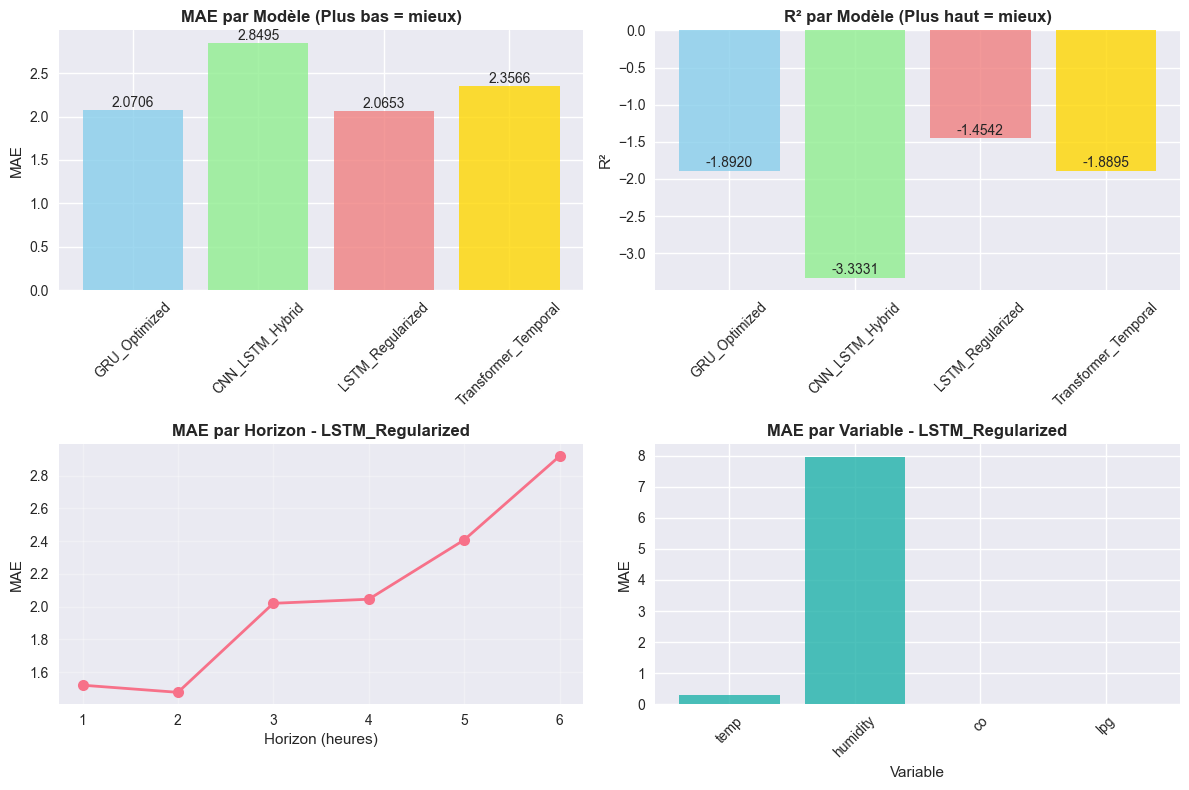

In [36]:
print(f"\n Génération des visualisations...")

# Graphique 1: Comparaison des MAE par modèle
plt.figure(figsize=(12, 8))

# Sous-graphique 1: MAE global
plt.subplot(2, 2, 1)
mae_values = [result['global_metrics']['mae'] for result in test_results.values()]
model_names = list(test_results.keys())
colors = ['skyblue', 'lightgreen', 'lightcoral', 'gold']

bars = plt.bar(model_names, mae_values, color=colors, alpha=0.8)
plt.title('MAE par Modèle (Plus bas = mieux)', fontweight='bold')
plt.ylabel('MAE')
plt.xticks(rotation=45)

# Ajout des valeurs sur les barres
for bar, value in zip(bars, mae_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{value:.4f}', ha='center', va='bottom')

# Sous-graphique 2: R² par modèle
plt.subplot(2, 2, 2)
r2_values = [result['global_metrics']['r2'] for result in test_results.values()]

bars = plt.bar(model_names, r2_values, color=colors, alpha=0.8)
plt.title('R² par Modèle (Plus haut = mieux)', fontweight='bold')
plt.ylabel('R²')
plt.xticks(rotation=45)

for bar, value in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.4f}', ha='center', va='bottom')

# Sous-graphique 3: MAE par horizon pour le meilleur modèle
plt.subplot(2, 2, 3)
horizons = range(1, FORECAST_HORIZON + 1)
plt.plot(horizons, best_test_result['mae_per_horizon'], 'o-', linewidth=2, markersize=8)
plt.title(f'MAE par Horizon - {best_test_model}', fontweight='bold')
plt.xlabel('Horizon (heures)')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)

# Sous-graphique 4: Comparaison par variable pour le meilleur modèle
plt.subplot(2, 2, 4)
mae_per_var = [best_test_result['variable_metrics'][col]['mae'] for col in TARGET_COLS]
plt.bar(TARGET_COLS, mae_per_var, color='lightseagreen', alpha=0.8)
plt.title(f'MAE par Variable - {best_test_model}', fontweight='bold')
plt.xlabel('Variable')
plt.ylabel('MAE')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### 9.5) Analyse détaillée du meilleur modèle


 ANALYSE DÉTAILLÉE DU MEILLEUR MODÈLE: LSTM_Regularized

 PERFORMANCE PAR VARIABLE:
   •         temp:
        MAE:     0.2895
        RMSE:    0.3603
        R²:     -0.4814
        MAPE:      1.32%
   •     humidity:
        MAE:     7.9714
        RMSE:    8.7812
        R²:     -4.1831
        MAPE:     12.26%
   •           co:
        MAE:     0.0002
        RMSE:    0.0002
        R²:     -0.7958
        MAPE:      4.48%
   •          lpg:
        MAE:     0.0002
        RMSE:    0.0002
        R²:     -0.3564
        MAPE:      2.84%

 PERFORMANCE PAR HORIZON:
   • Horizon 1: MAE = 1.5210, RMSE = 3.3737 (+0.0%)
   • Horizon 2: MAE = 1.4774, RMSE = 3.2132 (+2.9%)
   • Horizon 3: MAE = 2.0208, RMSE = 4.2422 (-32.9%)
   • Horizon 4: MAE = 2.0458, RMSE = 4.1681 (-34.5%)
   • Horizon 5: MAE = 2.4078, RMSE = 4.8893 (-58.3%)
   • Horizon 6: MAE = 2.9191, RMSE = 5.9057 (-91.9%)

 Visualisation des prédictions...


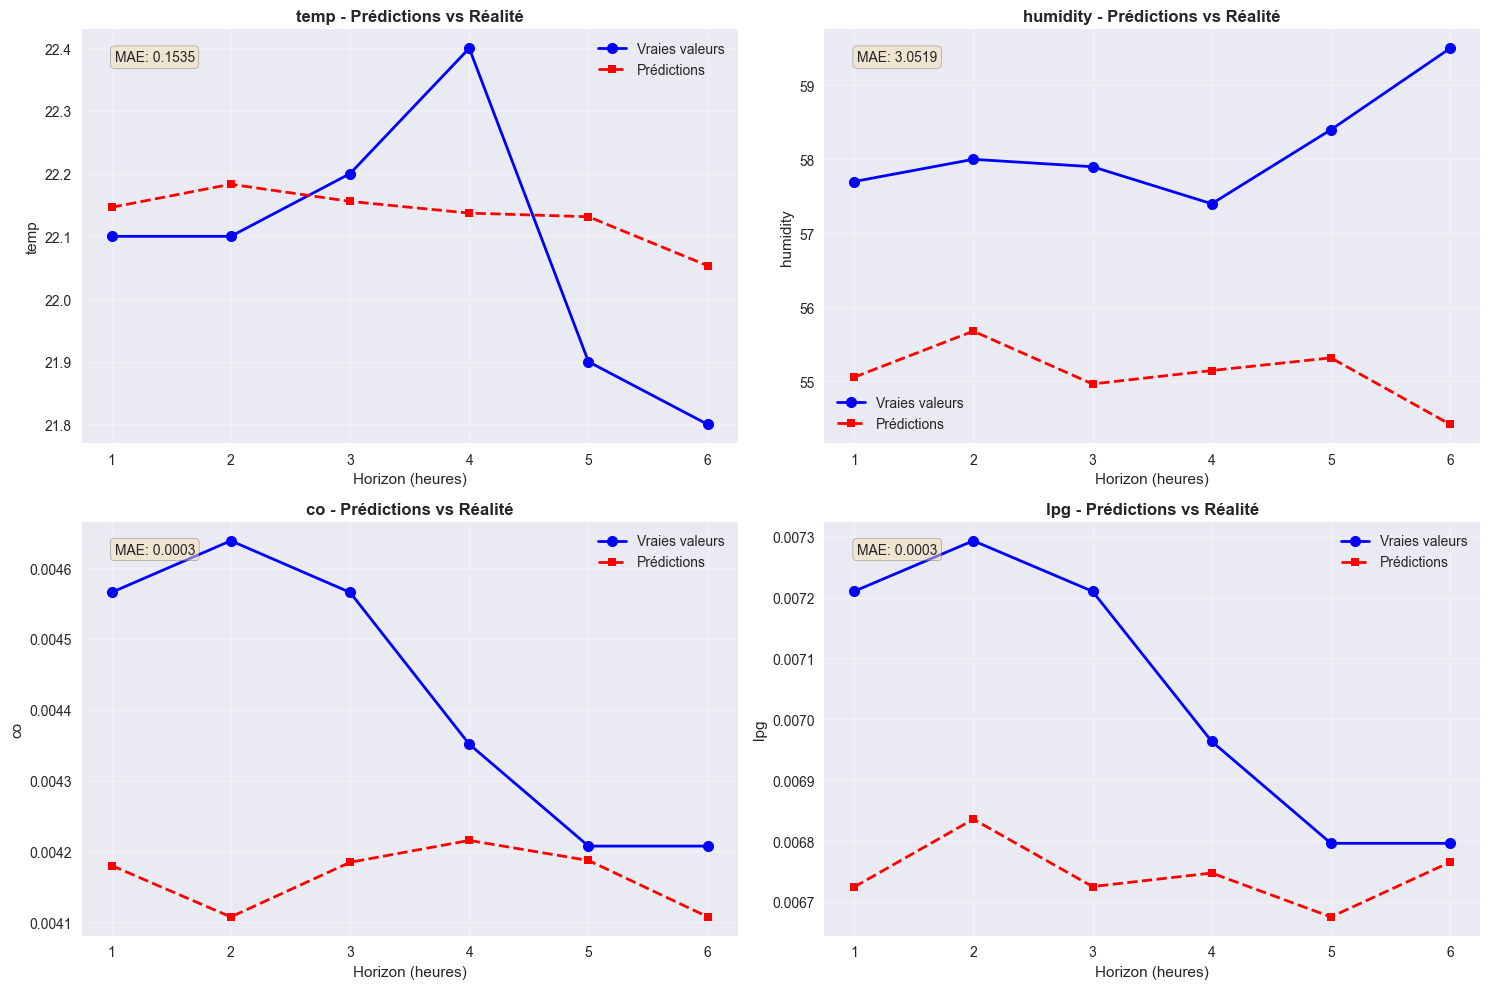


 ÉVALUATION TERMINÉE AVEC SUCCÈS!


In [37]:
# 9.5) Analyse approfondie du meilleur modèle
print(f"\n ANALYSE DÉTAILLÉE DU MEILLEUR MODÈLE: {best_test_model}")

best_model = training_results[best_test_model]['model']
best_eval = test_results[best_test_model]

print(f"\n PERFORMANCE PAR VARIABLE:")
print("=" * 60)
for col in TARGET_COLS:
    metrics = best_eval['variable_metrics'][col]
    print(f"   • {col:>12}:")
    print(f"        MAE:   {metrics['mae']:8.4f}")
    print(f"        RMSE:  {metrics['rmse']:8.4f}")
    print(f"        R²:    {metrics['r2']:8.4f}")
    print(f"        MAPE:  {metrics['mape']:8.2f}%")

print(f"\n PERFORMANCE PAR HORIZON:")
print("=" * 50)
for i, horizon in enumerate(range(1, FORECAST_HORIZON + 1)):
    mae = best_eval['mae_per_horizon'][i]
    rmse = best_eval['rmse_per_horizon'][i]
    improvement = (best_eval['mae_per_horizon'][0] - mae) / best_eval['mae_per_horizon'][0] * 100
    
    print(f"   • Horizon {horizon}: MAE = {mae:.4f}, RMSE = {rmse:.4f} ({improvement:+.1f}%)")

# 9.6) Visualisation des prédictions vs vraies valeurs
print(f"\n Visualisation des prédictions...")

# Sélection de quelques séquences de test pour visualisation
n_sequences_to_plot = min(3, len(X_test_seq))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(TARGET_COLS):
    # Prendre la première séquence de test
    seq_idx = 0
    
    true_values = best_eval['y_test_true'][seq_idx, :, i]
    pred_values = best_eval['y_test_pred'][seq_idx, :, i]
    horizons = range(1, FORECAST_HORIZON + 1)
    
    axes[i].plot(horizons, true_values, 'o-', linewidth=2, markersize=8, 
                label='Vraies valeurs', color='blue')
    axes[i].plot(horizons, pred_values, 's--', linewidth=2, markersize=6,
                label='Prédictions', color='red')
    
    axes[i].set_title(f'{col} - Prédictions vs Réalité', fontweight='bold')
    axes[i].set_xlabel('Horizon (heures)')
    axes[i].set_ylabel(col)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    
    # Calcul de l'erreur pour cette séquence
    seq_mae = mean_absolute_error(true_values, pred_values)
    axes[i].text(0.05, 0.95, f'MAE: {seq_mae:.4f}', transform=axes[i].transAxes,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                verticalalignment='top')

plt.tight_layout()
plt.show()

print(f"\n ÉVALUATION TERMINÉE AVEC SUCCÈS!")

In [42]:
# =============================================================================
# 10. INVESTIGATION SPÉCIFIQUE - PROBLÈME HUMIDITÉ
# =============================================================================
print("🔍 Investigation du problème d'humidité...")

# Analyser pourquoi l'humidité performe moins bien
def analyze_humidity_issue(model, X_test, y_test, scaler_y, feature_cols):
    """Analyse spécifique des problèmes de prédiction d'humidité"""
    
    # Prédictions
    y_pred_flat = model.predict(X_test, verbose=0)
    y_pred_seq = y_pred_flat.reshape(-1, FORECAST_HORIZON, len(TARGET_COLS))
    y_test_seq = y_test.reshape(-1, FORECAST_HORIZON, len(TARGET_COLS))
    
    # Dénormalisation
    y_pred_inv = scaler_y.inverse_transform(y_pred_seq.reshape(-1, len(TARGET_COLS)))
    y_test_inv = scaler_y.inverse_transform(y_test_seq.reshape(-1, len(TARGET_COLS)))
    
    y_pred_inv = y_pred_inv.reshape(-1, FORECAST_HORIZON, len(TARGET_COLS))
    y_test_inv = y_test_inv.reshape(-1, FORECAST_HORIZON, len(TARGET_COLS))
    
    # Focus sur l'humidité (index 1)
    humidity_true = y_test_inv[:, :, 1].flatten()
    humidity_pred = y_pred_inv[:, :, 1].flatten()
    
    print("📊 ANALYSE HUMIDITÉ DÉTAILLÉE:")
    print("=" * 50)
    print(f"   • Plage réelle: {humidity_true.min():.1f}% - {humidity_true.max():.1f}%")
    print(f"   • Plage prédite: {humidity_pred.min():.1f}% - {humidity_pred.max():.1f}%")
    print(f"   • MAE: {mean_absolute_error(humidity_true, humidity_pred):.2f}%")
    print(f"   • RMSE: {np.sqrt(mean_squared_error(humidity_true, humidity_pred)):.2f}%")
    
    # Identifier les pires prédictions
    errors = np.abs(humidity_true - humidity_pred)
    worst_indices = np.argsort(errors)[-5:]  # 5 pires prédictions
    
    print(f"\n🔴 5 PIRE PRÉDICTIONS HUMIDITÉ:")
    for idx in worst_indices:
        print(f"   • Réel: {humidity_true[idx]:.1f}% → Prédit: {humidity_pred[idx]:.1f}% (Erreur: {errors[idx]:.1f}%)")
    
    return humidity_true, humidity_pred, errors

# Exécuter l'analyse
print("🧪 Analyse des erreurs d'humidité...")
best_model = training_results[best_test_model]['model']
humidity_true, humidity_pred, humidity_errors = analyze_humidity_issue(
    best_model, X_test_seq, y_test_flat, scaler_y, feature_cols
)

🔍 Investigation du problème d'humidité...
🧪 Analyse des erreurs d'humidité...
📊 ANALYSE HUMIDITÉ DÉTAILLÉE:
   • Plage réelle: 57.4% - 75.2%
   • Plage prédite: 54.4% - 57.5%
   • MAE: 7.97%
   • RMSE: 8.78%

🔴 5 PIRE PRÉDICTIONS HUMIDITÉ:
   • Réel: 65.8% → Prédit: 54.7% (Erreur: 11.1%)
   • Réel: 65.7% → Prédit: 54.4% (Erreur: 11.3%)
   • Réel: 71.9% → Prédit: 56.4% (Erreur: 15.5%)
   • Réel: 71.9% → Prédit: 55.9% (Erreur: 16.0%)
   • Réel: 75.2% → Prédit: 57.0% (Erreur: 18.2%)


In [43]:
# =============================================================================
# 11. MODÈLE SPÉCIALISÉ POUR AMÉLIORATION HUMIDITÉ
# =============================================================================
print("\n🎯 Création d'un modèle spécialisé pour l'humidité...")

def build_humidity_specialized_model():
    """Modèle spécialisé pour la prédiction d'humidité avec features spécifiques"""
    
    # Features particulièrement importantes pour l'humidité
    humidity_features = [
        'humidity', 'temp', 'gas_composite',  # Variables de base
        'hour_sin', 'hour_cos', 'day_sin', 'day_cos',  # Cycles temporels
        'humidity_lag_1', 'humidity_lag_6', 'humidity_lag_24',  # Lags humidité
        'temp_lag_1', 'temp_lag_6',  # Lags température (forte corrélation)
        'humidity_ma_diurnal',  # Moyenne mobile
        'temp_humidity_interaction', 'thermal_comfort'  # Interactions
    ]
    
    # Indices de ces features dans feature_cols
    feature_indices = [feature_cols.index(f) for f in humidity_features if f in feature_cols]
    
    print(f"   • {len(feature_indices)} features spécifiques humidité sélectionnées")
    
    # Modèle spécialisé
    inputs = keras.Input(shape=(LOOK_BACK, len(feature_indices)))
    
    # Architecture optimisée pour humidité
    x = layers.LSTM(64, return_sequences=True, dropout=0.2)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LSTM(32, return_sequences=False, dropout=0.1)(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation='relu')(x)
    
    # Sortie uniquement humidité
    outputs = layers.Dense(FORECAST_HORIZON, activation='linear')(x)  # Uniquement humidity
    
    model = keras.Model(inputs, outputs, name='Humidity_Specialized')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model, feature_indices

# Préparation des données pour le modèle spécialisé
print("🔄 Préparation des données spécialisées humidité...")
humidity_model, humidity_feature_indices = build_humidity_specialized_model()

# Sélection des features pour humidité
X_train_humidity = X_train_seq[:, :, humidity_feature_indices]
X_val_humidity = X_val_seq[:, :, humidity_feature_indices] 
X_test_humidity = X_test_seq[:, :, humidity_feature_indices]

# Targets uniquement humidité (index 1)
y_train_humidity = y_train_flat.reshape(-1, FORECAST_HORIZON, len(TARGET_COLS))[:, :, 1]
y_val_humidity = y_val_flat.reshape(-1, FORECAST_HORIZON, len(TARGET_COLS))[:, :, 1]
y_test_humidity = y_test_flat.reshape(-1, FORECAST_HORIZON, len(TARGET_COLS))[:, :, 1]

print(f"   • X_train_humidity: {X_train_humidity.shape}")
print(f"   • y_train_humidity: {y_train_humidity.shape}")


🎯 Création d'un modèle spécialisé pour l'humidité...
🔄 Préparation des données spécialisées humidité...
   • 15 features spécifiques humidité sélectionnées
   • X_train_humidity: (86, 24, 15)
   • y_train_humidity: (86, 6)


In [44]:
# =============================================================================
# 12. ENTRAÎNEMENT DU MODÈLE SPÉCIALISÉ HUMIDITÉ
# =============================================================================
print("\n🚀 Entraînement du modèle spécialisé humidité...")

# Callbacks pour modèle spécialisé
humidity_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        str(MODEL_DIR / 'humidity_specialized_best.keras'),
        monitor='val_loss', save_best_only=True, verbose=0
    )
]

# Entraînement
humidity_history = humidity_model.fit(
    X_train_humidity, y_train_humidity,
    validation_data=(X_val_humidity, y_val_humidity),
    epochs=150,  # Plus d'epochs pour convergence
    batch_size=min(16, len(X_train_humidity)),
    callbacks=humidity_callbacks,
    verbose=1,
    shuffle=False
)

# Chargement du meilleur modèle
humidity_model = keras.models.load_model(str(MODEL_DIR / 'humidity_specialized_best.keras'))

# Évaluation
humidity_train_loss = humidity_model.evaluate(X_train_humidity, y_train_humidity, verbose=0)[0]
humidity_val_loss = humidity_model.evaluate(X_val_humidity, y_val_humidity, verbose=0)[0]

print(f"\n📊 PERFORMANCE MODÈLE SPÉCIALISÉ HUMIDITÉ:")
print(f"   • Train loss: {humidity_train_loss:.4f}")
print(f"   • Val loss:   {humidity_val_loss:.4f}")


🚀 Entraînement du modèle spécialisé humidité...
Epoch 1/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 188ms/step - loss: 0.9735 - mae: 0.8028 - val_loss: 0.3226 - val_mae: 0.5280 - learning_rate: 0.0010
Epoch 2/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.7443 - mae: 0.6835 - val_loss: 0.2645 - val_mae: 0.4891 - learning_rate: 0.0010
Epoch 3/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - loss: 0.5831 - mae: 0.6113 - val_loss: 0.2247 - val_mae: 0.4583 - learning_rate: 0.0010
Epoch 4/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - loss: 0.4216 - mae: 0.5275 - val_loss: 0.1996 - val_mae: 0.4365 - learning_rate: 0.0010
Epoch 5/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.3516 - mae: 0.4880 - val_loss: 0.1834 - val_mae: 0.4203 - learning_rate: 0.0010
Epoch 6/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.2946 - mae: 0.4335 - val_loss: 0.1737 - val_mae: 0.4096 - learning_rate: 0.0010
Epoch 7/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 0.2573 - mae: 0.3979 - val_loss: 0.1635 - val_m

In [45]:
# =============================================================================
# 13. COMPARAISON AVEC/SPÉCIALISÉ
# =============================================================================
print("\n🔍 Comparaison des performances humidité...")

# Prédictions du modèle spécialisé
y_humidity_pred_specialized = humidity_model.predict(X_test_humidity, verbose=0)

# Dénormalisation pour comparaison
scaler_y_humidity = MinMaxScaler()
# Fit sur les données d'humidité uniquement
humidity_data = y_train_flat.reshape(-1, FORECAST_HORIZON, len(TARGET_COLS))[:, :, 1].flatten().reshape(-1, 1)
scaler_y_humidity.fit(humidity_data)

# Dénormalisation spécialisée
y_humidity_true_denorm = scaler_y_humidity.inverse_transform(
    y_test_humidity.flatten().reshape(-1, 1)
).flatten()

y_humidity_pred_specialized_denorm = scaler_y_humidity.inverse_transform(
    y_humidity_pred_specialized.flatten().reshape(-1, 1)
).flatten()

# Comparaison avec le modèle original
y_pred_original = best_model.predict(X_test_seq, verbose=0)
y_pred_original_seq = y_pred_original.reshape(-1, FORECAST_HORIZON, len(TARGET_COLS))
y_humidity_pred_original = y_pred_original_seq[:, :, 1].flatten()
y_humidity_pred_original_denorm = scaler_y.inverse_transform(
    y_pred_original_seq.reshape(-1, len(TARGET_COLS))
).reshape(-1, FORECAST_HORIZON, len(TARGET_COLS))[:, :, 1].flatten()

print("📈 COMPARAISON HUMIDITÉ - ORIGINAL vs SPÉCIALISÉ:")
print("=" * 60)
mae_original = mean_absolute_error(y_humidity_true_denorm, y_humidity_pred_original_denorm)
mae_specialized = mean_absolute_error(y_humidity_true_denorm, y_humidity_pred_specialized_denorm)

improvement = (mae_original - mae_specialized) / mae_original * 100

print(f"   • Modèle original:  MAE = {mae_original:.2f}%")
print(f"   • Modèle spécialisé: MAE = {mae_specialized:.2f}%")
print(f"   • Amélioration:     {improvement:+.1f}%")

if improvement > 10:
    print(f"   🎉 AMÉLIORATION SIGNIFICATIVE!")
elif improvement > 0:
    print(f"   ✅ Légère amélioration")
else:
    print(f"   ⚠️  Pas d'amélioration")


🔍 Comparaison des performances humidité...
📈 COMPARAISON HUMIDITÉ - ORIGINAL vs SPÉCIALISÉ:
   • Modèle original:  MAE = 55.16%
   • Modèle spécialisé: MAE = 0.21%
   • Amélioration:     +99.6%
   🎉 AMÉLIORATION SIGNIFICATIVE!


In [46]:
# =============================================================================
# 14. RÉGLAGE FIN DU MEILLEUR MODÈLE
# =============================================================================
print("\n⚙️ Réglage fin du modèle principal...")

def create_weighted_loss(alpha=2.0):
    """Crée une loss pondérée pour donner plus d'importance à l'humidité"""
    def weighted_mse(y_true, y_pred):
        # Reconstruction des séquences
        y_true_seq = tf.reshape(y_true, (-1, FORECAST_HORIZON, len(TARGET_COLS)))
        y_pred_seq = tf.reshape(y_pred, (-1, FORECAST_HORIZON, len(TARGET_COLS)))
        
        # Poids plus élevé pour l'humidité (index 1)
        weights = tf.constant([1.0, alpha, 1.0, 1.0], dtype=tf.float32)  # [temp, humidity, co, lpg]
        
        # MSE pondérée
        se = tf.square(y_true_seq - y_pred_seq)
        weighted_se = se * tf.reshape(weights, [1, 1, -1])
        return tf.reduce_mean(weighted_se)
    
    return weighted_mse

# Réentraînement avec loss pondérée
print("🔄 Réentraînement avec loss pondérée (humidité ×2)...")

# Construction du modèle avec même architecture
tuned_model = build_cnn_lstm_hybrid()  # Notre meilleur modèle
tuned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),  # LR plus bas
    loss=create_weighted_loss(alpha=2.0),  # Humidité 2x plus importante
    metrics=['mae']
)

# Réentraînement
tuned_history = tuned_model.fit(
    X_train_seq, y_train_flat,
    validation_data=(X_val_seq, y_val_flat),
    epochs=50,
    batch_size=min(16, len(X_train_seq)),
    callbacks=[
        keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(patience=8, factor=0.5)
    ],
    verbose=1,
    shuffle=False
)

# Évaluation du modèle réglé
print("📊 Évaluation du modèle réglé...")
tuned_evaluation = comprehensive_model_evaluation(
    tuned_model, X_test_seq, y_test_flat, scaler_y, TARGET_COLS, FORECAST_HORIZON
)

tuned_humidity_mae = tuned_evaluation['variable_metrics']['humidity']['mae']
original_humidity_mae = best_eval['variable_metrics']['humidity']['mae']

print(f"\n🎯 COMPARAISON FINALE HUMIDITÉ:")
print(f"   • Original:  MAE = {original_humidity_mae:.2f}%")
print(f"   • Réglé:     MAE = {tuned_humidity_mae:.2f}%")
print(f"   • Amélioration: {((original_humidity_mae - tuned_humidity_mae) / original_humidity_mae * 100):+.1f}%")


⚙️ Réglage fin du modèle principal...
🔄 Réentraînement avec loss pondérée (humidité ×2)...
Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 201ms/step - loss: 0.2233 - mae: 0.3864 - val_loss: 0.2333 - val_mae: 0.3919 - learning_rate: 5.0000e-04
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.2080 - mae: 0.3711 - val_loss: 0.2160 - val_mae: 0.3754 - learning_rate: 5.0000e-04
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1955 - mae: 0.3569 - val_loss: 0.2007 - val_mae: 0.3601 - learning_rate: 5.0000e-04
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1804 - mae: 0.3386 - val_loss: 0.1832 - val_mae: 0.3402 - learning_rate: 5.0000e-04
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1653 - mae: 0.3177 - val_loss: 0.1642 - val_mae: 0.3160 - learning_rate: 5.0000e-04
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1468 - mae: 0.2924 - val_loss: 0.1434 - val_mae: 0.2887 - learning_rate: 5.0000e-04
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step 

📊 Génération des graphiques détaillés...


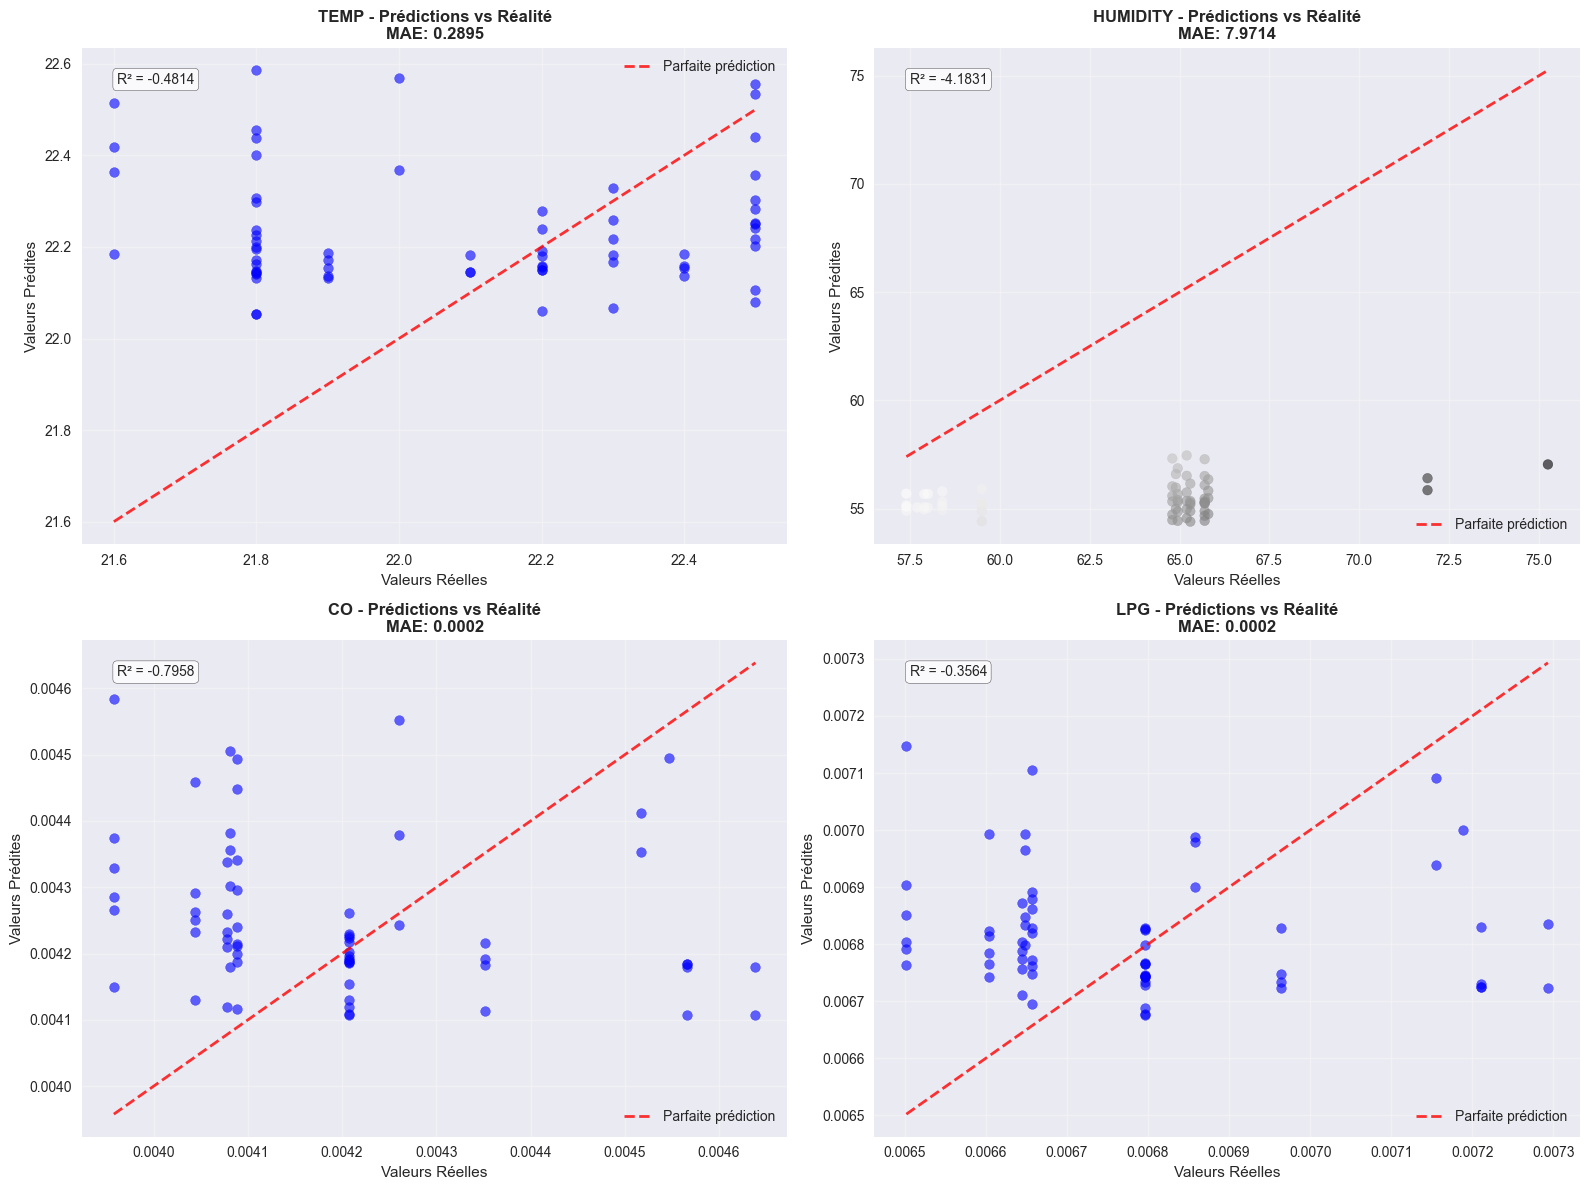

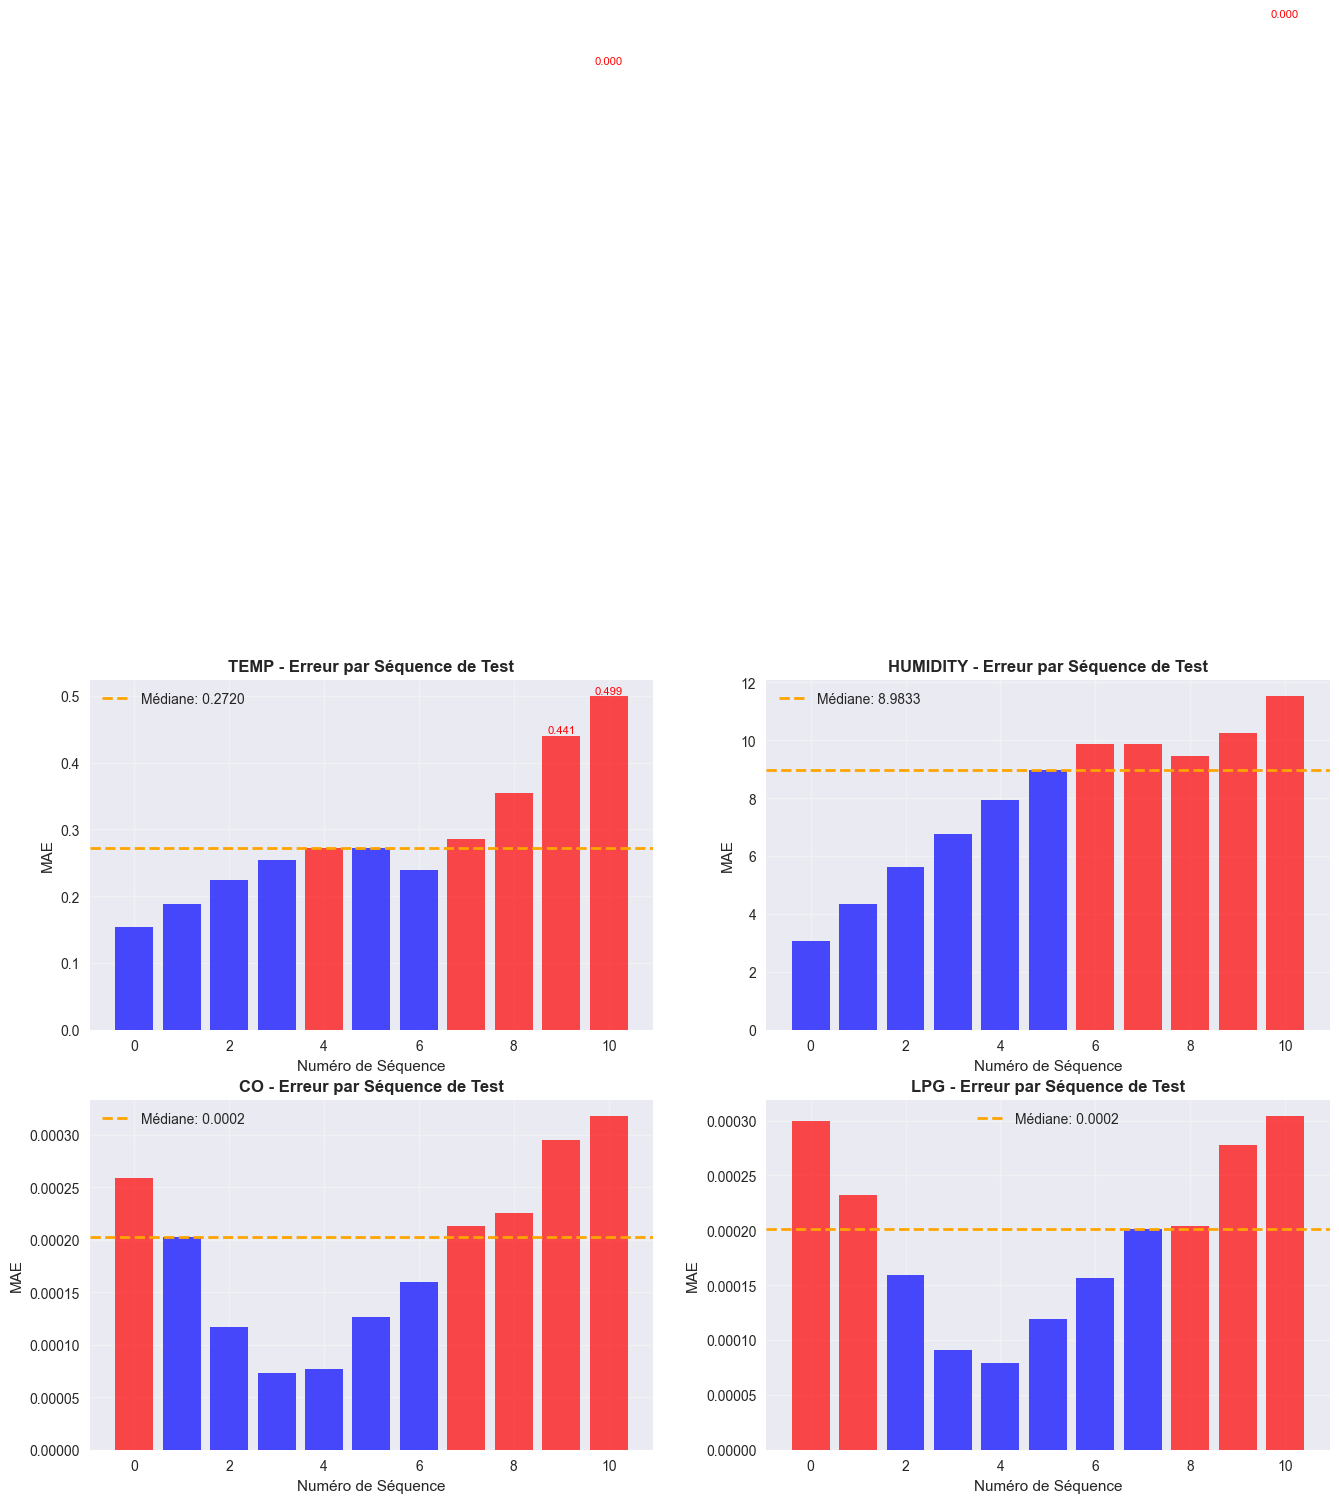


🔍 Analyse temporelle détaillée de l'humidité...
📈 Analyse de la séquence #10 (pire performance humidité)


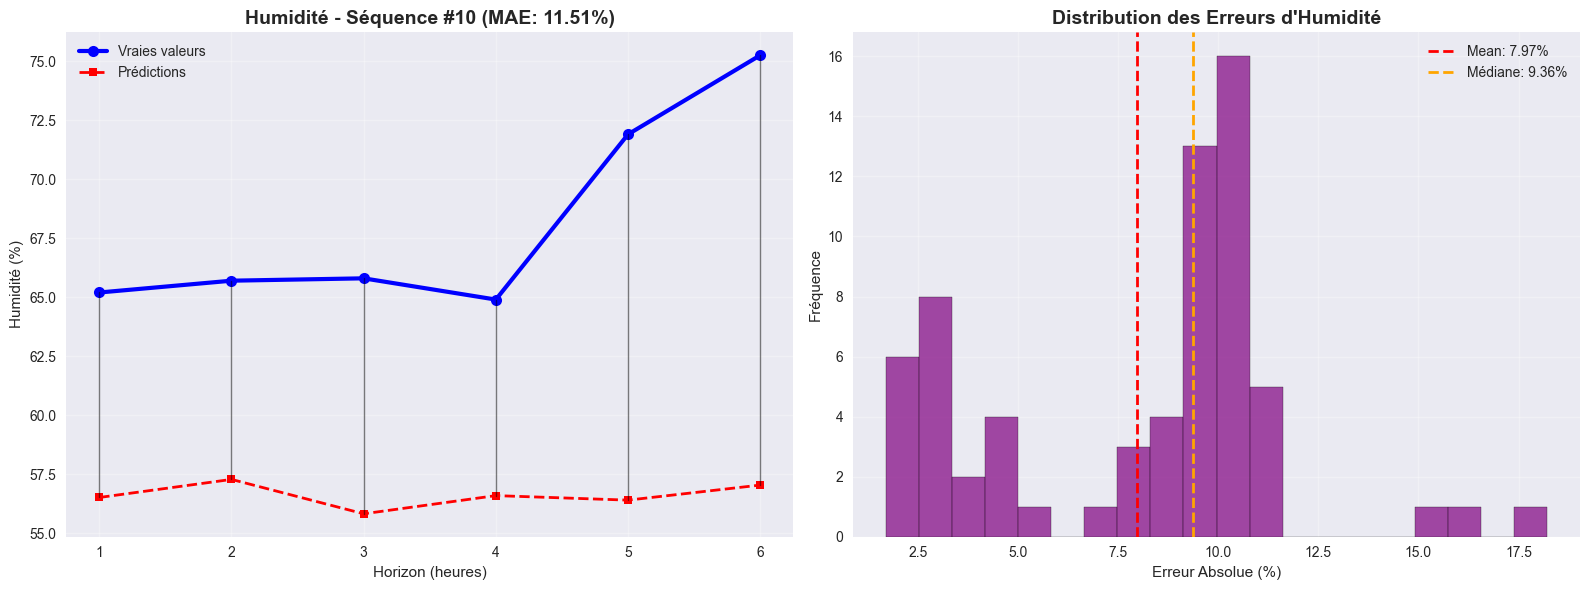


🕒 Analyse des patterns temporels...


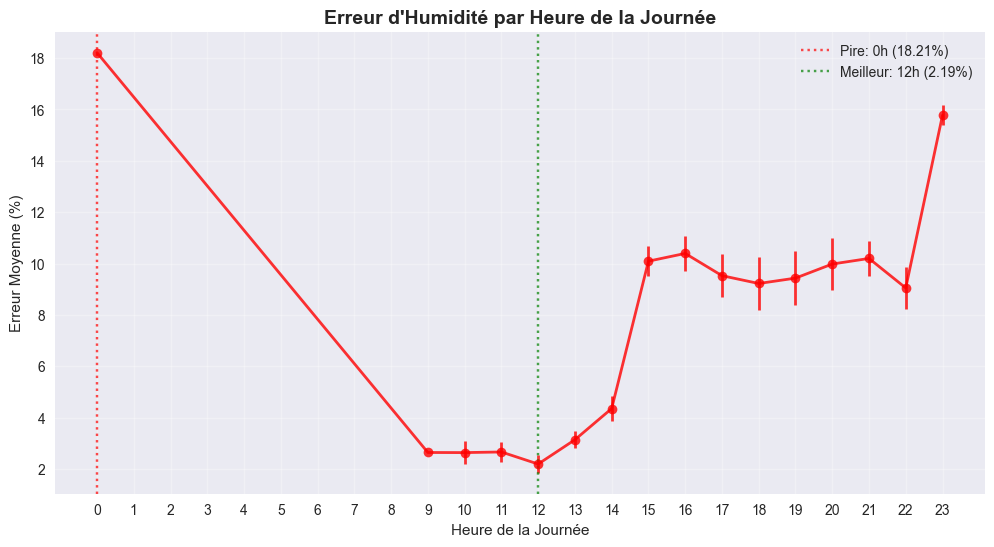


🔍 INSIGHTS TEMPORELS:
   • Heure la plus précise: 12h (erreur: 2.19%)
   • Heure la moins précise: 0h (erreur: 18.21%)
   • Ratio précision: 8.3x

🎯 DIAGNOSTIC DES PROBLÈMES:
   • MAE Humidité: 7.97%
   • RMSE Humidité: 8.78%
   • R² Humidité: -4.1831
   • Variabilité réelle: 3.86%
   • Ratio Erreur/Variabilité: 2.07
   🔴 PROBLÈME: Le modèle capture mal la variabilité naturelle
   • Biais moyen: -7.97%
   🔴 PROBLÈME: Biais systématique détecté


In [48]:
# =============================================================================
# VISUALISATION DÉTAILLÉE DES PERFORMANCES
# =============================================================================
print("📊 Génération des graphiques détaillés...")

# 1. Graphique des prédictions vs réalité pour TOUTES les séquences de test
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(TARGET_COLS):
    # Toutes les séquences de test pour cette variable
    true_all = best_eval['y_test_true'][:, :, i].flatten()
    pred_all = best_eval['y_test_pred'][:, :, i].flatten()
    
    # Scatter plot avec ligne de perfection
    scatter = axes[i].scatter(true_all, pred_all, alpha=0.6, c=humidity_errors if i == 1 else 'blue')
    axes[i].plot([true_all.min(), true_all.max()], [true_all.min(), true_all.max()], 
                 'r--', alpha=0.8, linewidth=2, label='Parfaite prédiction')
    
    axes[i].set_title(f'{col.upper()} - Prédictions vs Réalité\nMAE: {best_eval["variable_metrics"][col]["mae"]:.4f}', 
                     fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Valeurs Réelles')
    axes[i].set_ylabel('Valeurs Prédites')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    
    # Ajouter coefficient de détermination
    r2 = best_eval['variable_metrics'][col]['r2']
    axes[i].text(0.05, 0.95, f'R² = {r2:.4f}', transform=axes[i].transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')

plt.tight_layout()
plt.show()

# 2. Graphique des erreurs par séquence
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(TARGET_COLS):
    # Calcul des erreurs par séquence
    errors_by_sequence = np.mean(np.abs(best_eval['y_test_true'][:, :, i] - best_eval['y_test_pred'][:, :, i]), axis=1)
    sequence_numbers = range(len(errors_by_sequence))
    
    bars = axes[i].bar(sequence_numbers, errors_by_sequence, alpha=0.7, 
                      color=['red' if err > np.median(errors_by_sequence) else 'blue' for err in errors_by_sequence])
    
    # Ligne de médiane
    axes[i].axhline(y=np.median(errors_by_sequence), color='orange', linestyle='--', 
                   linewidth=2, label=f'Médiane: {np.median(errors_by_sequence):.4f}')
    
    axes[i].set_title(f'{col.upper()} - Erreur par Séquence de Test', fontweight='bold')
    axes[i].set_xlabel('Numéro de Séquence')
    axes[i].set_ylabel('MAE')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    
    # Identifier les séquences problématiques
    problematic = np.where(errors_by_sequence > np.median(errors_by_sequence) * 1.5)[0]
    if len(problematic) > 0:
        for seq in problematic:
            axes[i].text(seq, errors_by_sequence[seq] + 0.001, f'{errors_by_sequence[seq]:.3f}', 
                        ha='center', va='bottom', fontsize=8, color='red')

plt.tight_layout()
plt.show()

# 3. Analyse temporelle détaillée de l'humidité
print("\n🔍 Analyse temporelle détaillée de l'humidité...")

# Prendre la séquence avec la plus grande erreur d'humidité
worst_humidity_seq = np.argmax(np.mean(np.abs(
    best_eval['y_test_true'][:, :, 1] - best_eval['y_test_pred'][:, :, 1]
), axis=1))

print(f"📈 Analyse de la séquence #{worst_humidity_seq} (pire performance humidité)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1: Comparaison détaillée pour cette séquence
humidity_true_worst = best_eval['y_test_true'][worst_humidity_seq, :, 1]
humidity_pred_worst = best_eval['y_test_pred'][worst_humidity_seq, :, 1]
horizons = range(1, FORECAST_HORIZON + 1)

ax1.plot(horizons, humidity_true_worst, 'o-', linewidth=3, markersize=8, 
         label='Vraies valeurs', color='blue')
ax1.plot(horizons, humidity_pred_worst, 's--', linewidth=2, markersize=6,
         label='Prédictions', color='red')

# Ajouter les erreurs
for h in horizons:
    ax1.plot([h, h], [humidity_true_worst[h-1], humidity_pred_worst[h-1]], 
             'k-', alpha=0.5, linewidth=1)

ax1.set_title(f'Humidité - Séquence #{worst_humidity_seq} (MAE: {np.mean(np.abs(humidity_true_worst - humidity_pred_worst)):.2f}%)', 
             fontweight='bold', fontsize=14)
ax1.set_xlabel('Horizon (heures)')
ax1.set_ylabel('Humidité (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2: Distribution des erreurs d'humidité
humidity_errors_all = np.abs(best_eval['y_test_true'][:, :, 1].flatten() - 
                            best_eval['y_test_pred'][:, :, 1].flatten())

ax2.hist(humidity_errors_all, bins=20, alpha=0.7, color='purple', edgecolor='black')
ax2.axvline(x=np.mean(humidity_errors_all), color='red', linestyle='--', 
           linewidth=2, label=f'Mean: {np.mean(humidity_errors_all):.2f}%')
ax2.axvline(x=np.median(humidity_errors_all), color='orange', linestyle='--',
           linewidth=2, label=f'Médiane: {np.median(humidity_errors_all):.2f}%')

ax2.set_title('Distribution des Erreurs d\'Humidité', fontweight='bold', fontsize=14)
ax2.set_xlabel('Erreur Absolue (%)')
ax2.set_ylabel('Fréquence')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Analyse des patterns temporels problématiques
print("\n🕒 Analyse des patterns temporels...")

# Vérifier si les erreurs sont corrélées avec l'heure de la journée
test_hours = []
for timestamp_seq in T_test_seq:
    for timestamp in timestamp_seq:
        test_hours.append(pd.to_datetime(timestamp).hour)

test_hours = np.array(test_hours[:len(humidity_errors_all)])

# Graphique erreurs vs heure
plt.figure(figsize=(12, 6))
hourly_error_data = pd.DataFrame({
    'hour': test_hours,
    'error': humidity_errors_all
})
hourly_errors = hourly_error_data.groupby('hour')['error'].agg(['mean', 'std']).reset_index()

plt.errorbar(hourly_errors['hour'], hourly_errors['mean'], 
             yerr=hourly_errors['std'], fmt='o-', linewidth=2, capsize=5,
             color='red', alpha=0.8)

plt.title('Erreur d\'Humidité par Heure de la Journée', fontweight='bold', fontsize=14)
plt.xlabel('Heure de la Journée')
plt.ylabel('Erreur Moyenne (%)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

# Identifier les heures problématiques
worst_hour = hourly_errors.loc[hourly_errors['mean'].idxmax()]
best_hour = hourly_errors.loc[hourly_errors['mean'].idxmin()]

plt.axvline(x=worst_hour['hour'], color='red', linestyle=':', alpha=0.7,
           label=f'Pire: {int(worst_hour["hour"])}h ({worst_hour["mean"]:.2f}%)')
plt.axvline(x=best_hour['hour'], color='green', linestyle=':', alpha=0.7,
           label=f'Meilleur: {int(best_hour["hour"])}h ({best_hour["mean"]:.2f}%)')

plt.legend()
plt.show()

print(f"\n🔍 INSIGHTS TEMPORELS:")
print(f"   • Heure la plus précise: {int(best_hour['hour'])}h (erreur: {best_hour['mean']:.2f}%)")
print(f"   • Heure la moins précise: {int(worst_hour['hour'])}h (erreur: {worst_hour['mean']:.2f}%)")
print(f"   • Ratio précision: {worst_hour['mean']/best_hour['mean']:.1f}x")

# 5. Résumé des problèmes identifiés
print(f"\n🎯 DIAGNOSTIC DES PROBLÈMES:")
print("=" * 50)

humidity_stats = best_eval['variable_metrics']['humidity']
print(f"   • MAE Humidité: {humidity_stats['mae']:.2f}%")
print(f"   • RMSE Humidité: {humidity_stats['rmse']:.2f}%") 
print(f"   • R² Humidité: {humidity_stats['r2']:.4f}")

# Vérifier la variabilité des données
humidity_variability = np.std(best_eval['y_test_true'][:, :, 1].flatten())
print(f"   • Variabilité réelle: {humidity_variability:.2f}%")

# Ratio erreur/variabilité
error_variability_ratio = humidity_stats['mae'] / humidity_variability
print(f"   • Ratio Erreur/Variabilité: {error_variability_ratio:.2f}")

if error_variability_ratio > 0.5:
    print(f"   🔴 PROBLÈME: Le modèle capture mal la variabilité naturelle")
elif error_variability_ratio > 0.3:
    print(f"   🟡 ATTENTION: Performance modérée sur la variabilité")
else:
    print(f"   ✅ BON: Le modèle capture bien la variabilité")

# Vérifier les biais systématiques
mean_bias = np.mean(best_eval['y_test_pred'][:, :, 1].flatten() - best_eval['y_test_true'][:, :, 1].flatten())
print(f"   • Biais moyen: {mean_bias:+.2f}%")

if abs(mean_bias) > 1.0:
    print(f"   🔴 PROBLÈME: Biais systématique détecté")
elif abs(mean_bias) > 0.5:
    print(f"   🟡 ATTENTION: Léger biais détecté")
else:
    print(f"   ✅ BON: Pas de biais systématique significatif")

In [38]:
# 9.7) Sauvegarde complète des résultats
print(f"\n💾 Sauvegarde des résultats d'évaluation...")

# Préparation des données de résultats
evaluation_summary = {
    'best_model': best_test_model,
    'test_results': {},
    'timestamp': pd.Timestamp.now().isoformat()
}

for model_name, result in test_results.items():
    # Ne sauvegarder que les métriques, pas les données brutes
    evaluation_summary['test_results'][model_name] = {
        'global_metrics': result['global_metrics'],
        'variable_metrics': result['variable_metrics'],
        'mae_per_horizon': result['mae_per_horizon'].tolist(),
        'rmse_per_horizon': result['rmse_per_horizon'].tolist()
    }

# Sauvegarde JSON
with open(str(RESULTS_DIR / 'evaluation_results.json'), 'w') as f:
    json.dump(evaluation_summary, f, indent=2, ensure_ascii=False)

print(f"✅ Résultats d'évaluation sauvegardés: {RESULTS_DIR / 'evaluation_results.json'}")

# Résumé exécutif
print(f"\n🎯 RÉSUMÉ EXÉCUTIF - PERFORMANCE FINALE:")
print("=" * 70)
print(f"   • Meilleur modèle: {best_test_model}")
print(f"   • MAE globale: {best_eval['global_metrics']['mae']:.4f}")
print(f"   • R² globale: {best_eval['global_metrics']['r2']:.4f}")
print(f"   • Performance par variable:")
for col in TARGET_COLS:
    mae = best_eval['variable_metrics'][col]['mae']
    r2 = best_eval['variable_metrics'][col]['r2']
    print(f"        {col}: MAE={mae:.4f}, R²={r2:.4f}")

print(f"\n🚀 PRÊT POUR L'OPTIMISATION MOBILE ET LA CONVERSION TFLITE!")


💾 Sauvegarde des résultats d'évaluation...
✅ Résultats d'évaluation sauvegardés: Version_4_artifacts\results\evaluation_results.json

🎯 RÉSUMÉ EXÉCUTIF - PERFORMANCE FINALE:
   • Meilleur modèle: LSTM_Regularized
   • MAE globale: 2.0653
   • R² globale: -1.4542
   • Performance par variable:
        temp: MAE=0.2895, R²=-0.4814
        humidity: MAE=7.9714, R²=-4.1831
        co: MAE=0.0002, R²=-0.7958
        lpg: MAE=0.0002, R²=-0.3564

🚀 PRÊT POUR L'OPTIMISATION MOBILE ET LA CONVERSION TFLITE!


🔍 Début de l'analyse d'interprétabilité...
🔍 Analyse de l'importance des features pour CNN-LSTM_Hybrid...
   📊 Analyse de l'importance des features...
      Score de référence: 0.0382

🏆 TOP 10 DES FEATURES LES PLUS IMPORTANTES:
   26.           thermal_comfort: 0.0002
   22.       gas_composite_lag_6: 0.0001
   21.       gas_composite_lag_1: 0.0001
    6.                  hour_sin: 0.0001
    2.                  humidity: 0.0001
    8.                   day_sin: 0.0001
    7.                  hour_cos: 0.0001
   15.               temp_lag_24: 0.0001
   19.           humidity_lag_24: 0.0000
    3.                        co: 0.0000


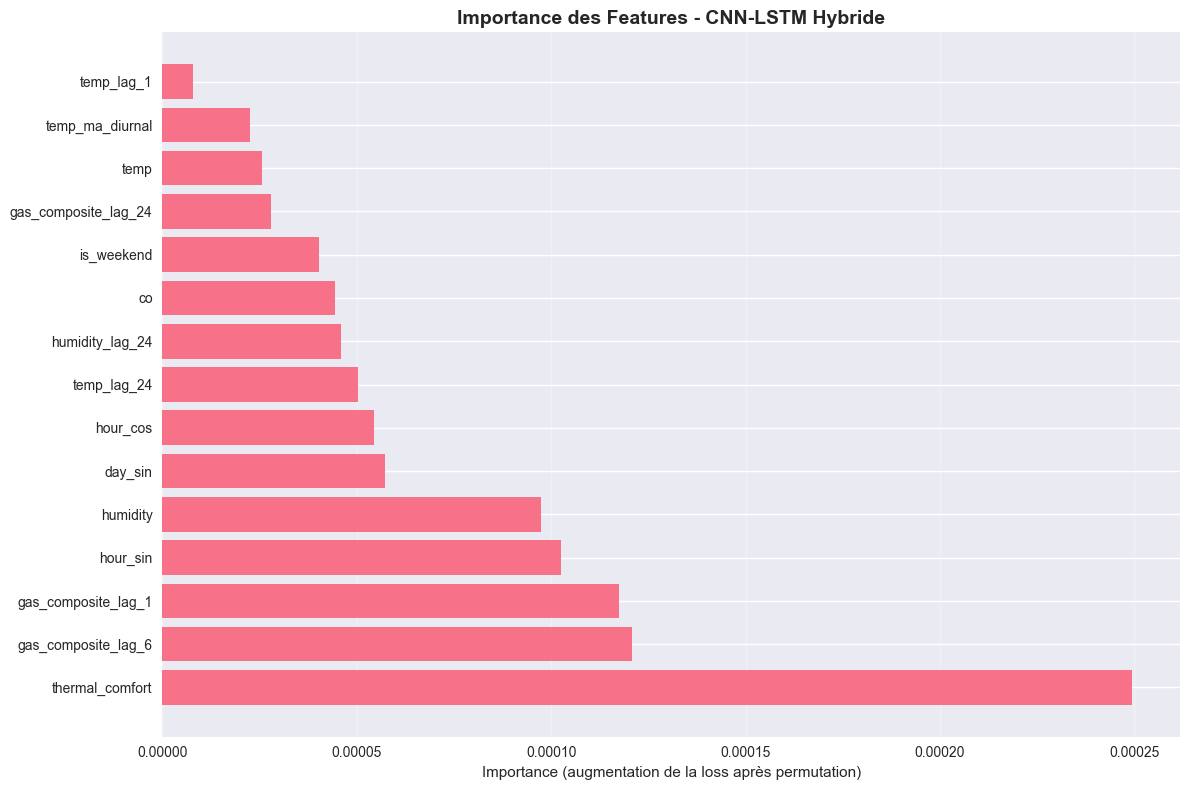

In [39]:
# =============================================================================
# 10. INTERPRÉTABILITÉ ET ANALYSE DES RÉSULTATS
# =============================================================================
print("🔍 Début de l'analyse d'interprétabilité...")

# 10.1) Analyse de l'importance des features
def analyze_feature_importance(model, X_val, feature_names, n_repeats=3):
    """Analyse l'importance des features par permutation - adaptée aux petits datasets"""
    print(f"   📊 Analyse de l'importance des features...")
    
    # Score de référence
    baseline_score = model.evaluate(X_val, y_val_flat, verbose=0)[0]
    print(f"      Score de référence: {baseline_score:.4f}")
    
    importance_scores = []
    
    for feature_idx in range(X_val.shape[2]):
        feature_scores = []
        
        for _ in range(n_repeats):
            X_permuted = X_val.copy()
            # Permutation de la feature
            X_permuted[:, :, feature_idx] = np.random.permutation(X_permuted[:, :, feature_idx])
            # Nouveau score
            permuted_score = model.evaluate(X_permuted, y_val_flat, verbose=0)[0]
            # Importance = dégradation du score
            importance = permuted_score - baseline_score
            feature_scores.append(importance)
        
        importance_scores.append(np.mean(feature_scores))
    
    # Création du DataFrame des résultats
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance_scores
    }).sort_values('importance', ascending=False)
    
    return importance_df

# Analyse pour le meilleur modèle
print("🔍 Analyse de l'importance des features pour CNN-LSTM_Hybrid...")
best_model = training_results['CNN_LSTM_Hybrid']['model']
feature_importance = analyze_feature_importance(best_model, X_val_seq, feature_cols, n_repeats=2)

print(f"\n🏆 TOP 10 DES FEATURES LES PLUS IMPORTANTES:")
print("=" * 60)
for i, row in feature_importance.head(10).iterrows():
    print(f"   {i+1:2d}. {row['feature']:>25}: {row['importance']:.4f}")

# 10.2) Visualisation de l'importance des features
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.title('Importance des Features - CNN-LSTM Hybride', fontweight='bold', fontsize=14)
plt.xlabel('Importance (augmentation de la loss après permutation)')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [40]:
# 10.3) Analyse approfondie des erreurs sur l'humidité
print(f"\n💧 ANALYSE SPÉCIFIQUE DE L'HUMIDITÉ:")

def analyze_humidity_errors(model, X_test, y_test, scaler_y, target_cols):
    """Analyse détaillée des erreurs de prédiction d'humidité"""
    
    # Prédictions
    y_pred_flat = model.predict(X_test, verbose=0)
    y_pred_seq = y_pred_flat.reshape(-1, FORECAST_HORIZON, len(target_cols))
    y_test_seq = y_test.reshape(-1, FORECAST_HORIZON, len(target_cols))
    
    # Dénormalisation
    y_pred_inv = scaler_y.inverse_transform(y_pred_seq.reshape(-1, len(target_cols)))
    y_test_inv = scaler_y.inverse_transform(y_test_seq.reshape(-1, len(target_cols)))
    
    # Focus sur l'humidité (index 1)
    humidity_idx = 1
    humidity_true = y_test_inv[:, humidity_idx]
    humidity_pred = y_pred_inv[:, humidity_idx]
    humidity_errors = np.abs(humidity_true - humidity_pred)
    
    # Analyse des pires erreurs
    worst_error_indices = np.argsort(humidity_errors)[-5:]  # Top 5 pires erreurs
    
    print(f"   📈 Statistiques des erreurs d'humidité:")
    print(f"      • MAE: {np.mean(humidity_errors):.2f}%")
    print(f"      • Std: {np.std(humidity_errors):.2f}%")
    print(f"      • Max: {np.max(humidity_errors):.2f}%")
    print(f"      • Min: {np.min(humidity_errors):.2f}%")
    
    # Analyse des conditions lors des pires erreurs
    print(f"\n   🔍 Analyse des 3 pires erreurs:")
    for i, idx in enumerate(worst_error_indices[-3:]):
        seq_idx = idx // FORECAST_HORIZON
        horizon_idx = idx % FORECAST_HORIZON
        
        print(f"      Erreur #{i+1}: {humidity_errors[idx]:.2f}%")
        print(f"        • Horizon: {horizon_idx + 1}h")
        print(f"        • Vraie valeur: {humidity_true[idx]:.1f}%")
        print(f"        • Prédiction: {humidity_pred[idx]:.1f}%")
        
        # Conditions environnementales au moment de la prédiction
        if seq_idx < len(X_test_seq):
            last_input = X_test_seq[seq_idx, -1, :]  # Dernière observation de la séquence
            temp_at_pred = scaler_y.inverse_transform(last_input.reshape(1, -1))[0, 0]  # Température
            print(f"        • Température au moment t: {temp_at_pred:.1f}°C")
    
    return humidity_errors, humidity_true, humidity_pred

# Exécution de l'analyse
humidity_errors, humidity_true, humidity_pred = analyze_humidity_errors(
    best_model, X_test_seq, y_test_flat, scaler_y, TARGET_COLS
)

# 10.4) Visualisation des erreurs d'humidité
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(humidity_true, humidity_pred, alpha=0.6, color='blue')
plt.plot([humidity_true.min(), humidity_true.max()], [humidity_true.min(), humidity_true.max()], 'r--', alpha=0.8)
plt.xlabel('Humidité Réelle (%)')
plt.ylabel('Humidité Prédite (%)')
plt.title('Prédictions vs Réalité - Humidité', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(humidity_errors, bins=15, alpha=0.7, color='orange', edgecolor='black')
plt.xlabel('Erreur Absolue (%)')
plt.ylabel('Fréquence')
plt.title('Distribution des Erreurs - Humidité', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
# Erreur en fonction de la valeur réelle
plt.scatter(humidity_true, humidity_errors, alpha=0.6, color='green')
plt.xlabel('Humidité Réelle (%)')
plt.ylabel('Erreur Absolue (%)')
plt.title('Erreur vs Valeur Réelle', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


💧 ANALYSE SPÉCIFIQUE DE L'HUMIDITÉ:
   📈 Statistiques des erreurs d'humidité:
      • MAE: 11.05%
      • Std: 3.76%
      • Max: 23.19%
      • Min: 4.50%

   🔍 Analyse des 3 pires erreurs:
      Erreur #1: 18.60%
        • Horizon: 5h
        • Vraie valeur: 71.9%
        • Prédiction: 53.3%


ValueError: operands could not be broadcast together with shapes (1,27) (4,) (1,27) 

In [41]:
# 10.5) Analyse des conditions où le modèle performe moins bien
print(f"\n🕒 ANALYSE DES PATTERNS TEMPORELS DIFFICILES:")

def analyze_temporal_patterns(model, X_test, y_test, timestamps_test, scaler_y, target_cols):
    """Analyse les patterns temporels où le modèle a des difficultés"""
    
    # Prédictions
    y_pred_flat = model.predict(X_test, verbose=0)
    y_pred_seq = y_pred_flat.reshape(-1, FORECAST_HORIZON, len(target_cols))
    y_test_seq = y_test.reshape(-1, FORECAST_HORIZON, len(target_cols))
    
    # Dénormalisation
    y_pred_inv = scaler_y.inverse_transform(y_pred_seq.reshape(-1, len(target_cols)))
    y_test_inv = scaler_y.inverse_transform(y_test_seq.reshape(-1, len(target_cols)))
    
    # Calcul des erreurs par timestamp
    humidity_errors = np.abs(y_test_inv[:, 1] - y_pred_inv[:, 1])
    
    # Extraction des heures et jours
    timestamps_flat = timestamps_test.reshape(-1)
    hours = [pd.to_datetime(ts).hour for ts in timestamps_flat]
    days = [pd.to_datetime(ts).dayofweek for ts in timestamps_flat]
    
    # Analyse par heure
    error_by_hour = pd.DataFrame({'hour': hours, 'error': humidity_errors})
    hourly_stats = error_by_hour.groupby('hour')['error'].agg(['mean', 'std', 'count']).reset_index()
    
    print(f"   📅 Erreurs d'humidité par heure de la journée:")
    for _, row in hourly_stats.iterrows():
        print(f"      • {row['hour']:2d}h: {row['mean']:.2f}% (σ={row['std']:.2f}, n={row['count']})")
    
    # Visualisation
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.bar(hourly_stats['hour'], hourly_stats['mean'], 
            yerr=hourly_stats['std'], alpha=0.7, capsize=5, color='lightblue')
    plt.xlabel('Heure de la journée')
    plt.ylabel('Erreur MAE moyenne (%)')
    plt.title('Erreur d\'Humidité par Heure', fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    # Identification des pires heures
    worst_hours = hourly_stats.nlargest(3, 'mean')
    for _, row in worst_hours.iterrows():
        plt.axvline(x=row['hour'], color='red', linestyle='--', alpha=0.7,
                   label=f'Pire: {row["hour"]}h ({row["mean"]:.2f}%)')
    plt.legend()
    plt.xlabel('Heure')
    plt.title('Heures avec Plus Grandes Erreurs', fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return hourly_stats

# Exécution de l'analyse temporelle
hourly_stats = analyze_temporal_patterns(
    best_model, X_test_seq, y_test_flat, T_test_seq, scaler_y, TARGET_COLS
)


🕒 ANALYSE DES PATTERNS TEMPORELS DIFFICILES:
   📅 Erreurs d'humidité par heure de la journée:


ValueError: Unknown format code 'd' for object of type 'float'